# ML Disease Prediction Model

## 1. Data Exploration, Visualisations, and Summary:
The first steps we need to perform are:
Download the dataset, prepare a summary of features, including data type
(numerical/categorical), and assess the amount of missing data and outliers in
individual features. Conduct initial exploration with visualisation and statistical
analysis of the features.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

disease_test= pd.read_csv('disease_test-1.csv')
disease_train= pd.read_csv('disease_train-1.csv')
predictedTarget= pd.read_csv('predictedTarget-1.csv')

In [2]:
disease_test.head()

,id,age,gender,sick,pregnant,test_X1,test_X2,test_X3,test_X4,test_X5,...,enlargement,tumor,disorder,medication_A,medication_B,mental_health,mood_stabiliser,surgery,treatment_type1,suspect
0,PA6001,22,female,no,no,0.500,1.7,83.0,0.86,97.0,...,no,no,no,no,no,no,no,no,no,no
1,PA6002,42,male,no,no,0.060,2.0,79.0,0.81,98.0,...,no,no,no,no,no,no,no,no,no,no
2,PA6003,42,male,no,no,0.045,2.1,111.0,0.89,125.0,...,no,no,no,no,no,no,no,no,no,no
3,PA6004,42,female,no,no,1.900,2.0,114.0,1.33,86.0,...,no,no,no,no,no,no,no,no,no,no
4,PA6005,55,male,no,no,0.570,1.4,75.0,0.72,104.0,...,no,no,no,no,no,yes,no,no,no,no


In [3]:
predictedTarget.head()

,id,predicted_target
0,PA6001,NaN
1,PA6002,NaN
2,PA6003,NaN
3,PA6004,NaN
4,PA6005,NaN


In [4]:
disease_train.index
disease_train.head().T

,0,1,2,3,4
id,PA1001,PA1002,PA1003,PA1004,PA1005
age,59,48,77,42,38
gender,male,female,male,female,female
sick,no,no,no,no,no
pregnant,no,no,no,no,no
test_X1,7.8,1.5,7.3,1.2,0.6
test_X2,NaN,2.5,1.2,2.5,1.9
test_X3,89.0,101.0,57.0,106.0,95.0
test_X4,0.85,0.97,1.28,0.98,NaN
test_X5,105.0,104.0,44.0,108.0,NaN


In [5]:
disease_train.shape

(4250, 24)

In [6]:
disease_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4250 entries, 0 to 4249
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               4250 non-null   object 
 1   age              4250 non-null   int64  
 2   gender           4109 non-null   object 
 3   sick             4250 non-null   object 
 4   pregnant         4250 non-null   object 
 5   test_X1          3839 non-null   float64
 6   test_X2          3007 non-null   float64
 7   test_X3          4034 non-null   float64
 8   test_X4          3858 non-null   float64
 9   test_X5          3863 non-null   float64
 10  test_X6          154 non-null    float64
 11  concern_type1    4250 non-null   object 
 12  concern_type2    4250 non-null   object 
 13  enlargement      4250 non-null   object 
 14  tumor            4250 non-null   object 
 15  disorder         4250 non-null   object 
 16  medication_A     4250 non-null   object 
 17  medication_B  

In [7]:
missing_values = disease_train.isnull().sum()
print('\nMissing values per feature:')
print(missing_values)


Missing values per feature:
id                    0
age                   0
gender              141
sick                  0
pregnant              0
test_X1             411
test_X2            1243
test_X3             216
test_X4             392
test_X5             387
test_X6            4096
concern_type1         0
concern_type2         0
enlargement           0
tumor                 0
disorder              0
medication_A          0
medication_B          0
mental_health         0
mood_stabiliser       0
surgery               0
treatment_type1       0
suspect               0
target                0
dtype: int64


<Axes: xlabel='target', ylabel='count'>

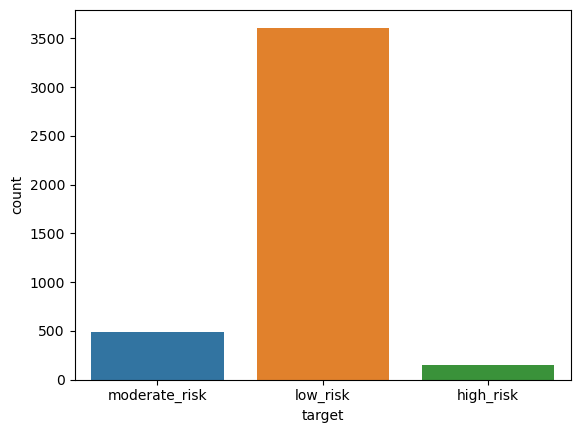

In [8]:
sns.countplot(x='target', data=disease_train)

In [9]:
COLUMNS = ['id', 'age', 'gender', 'sick', 'pregnant','test_X1', 'test_X2', 
         'test_X3','test_X4', 'test_X5', 'test_X6', 'concern_type1',
               'concern_type2', 'enlargement', 'tumor', 'disorder',
               'medication_A', 'medication_B', 'mental_health',
               'mood_stabiliser', 'surgery', 'treatment_type1', 'suspect' ]

In [10]:
categorical = ['gender', 'sick', 'pregnant', 'concern_type1',
               'concern_type2', 'enlargement', 'tumor', 'disorder',
               'medication_A', 'medication_B', 'mental_health',
               'mood_stabiliser', 'surgery', 'treatment_type1', 'suspect']
numerical =  ['age', 'test_X1', 'test_X2', 'test_X3',
              'test_X4', 'test_X5', 'test_X6']

## Numeric variables

In [11]:
dtn = disease_train[numerical].describe()
dtn

,age,test_X1,test_X2,test_X3,test_X4,test_X5,test_X6
count,4250.000000,3839.000000,3007.000000,4034.000000,3858.000000,3863.000000,154.000000
mean,67.374824,7.342463,2.035580,104.919623,0.970846,110.090834,23.325974
std,1004.518821,32.657963,0.920404,35.496255,0.162474,39.837621,5.317032
min,1.000000,0.005000,0.050000,2.000000,0.250000,1.400000,8.400000
25%,37.000000,0.600000,1.600000,87.000000,0.870000,92.000000,20.000000
50%,55.000000,1.500000,1.900000,102.000000,0.960000,107.000000,24.000000
75%,67.000000,3.000000,2.300000,121.000000,1.060000,125.000000,27.000000
max,65526.000000,530.000000,18.000000,430.000000,1.960000,642.000000,45.000000


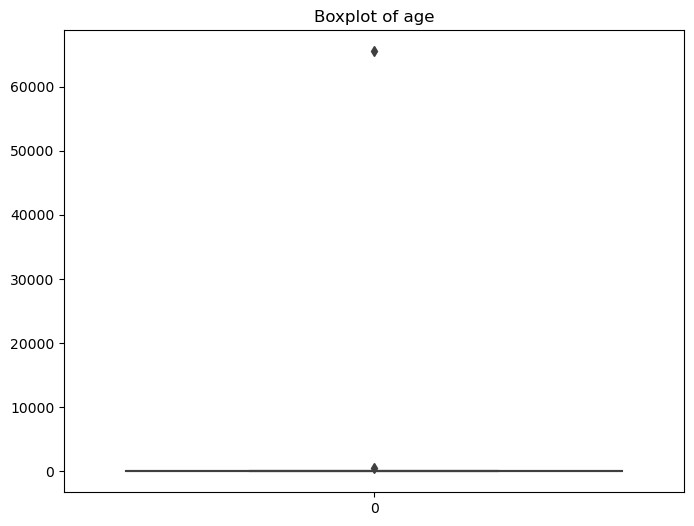

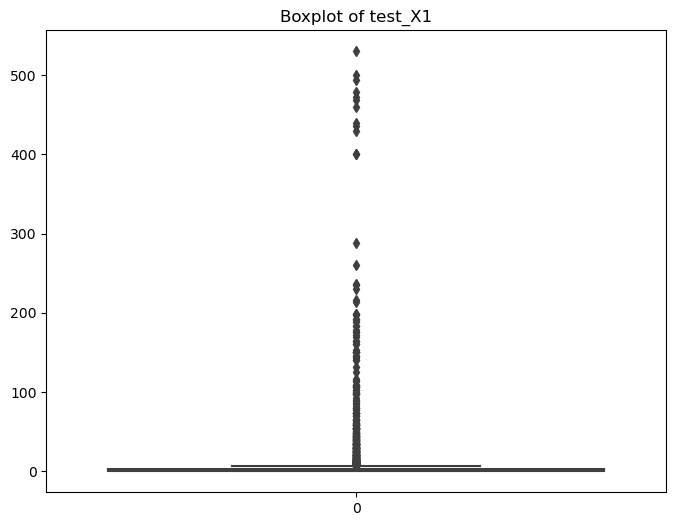

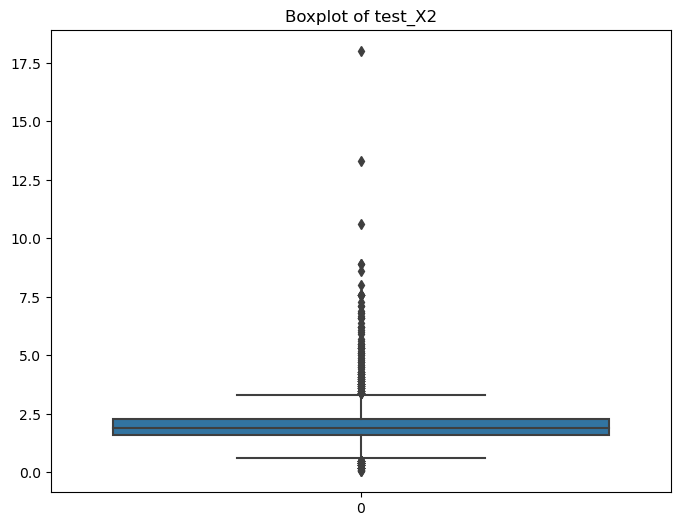

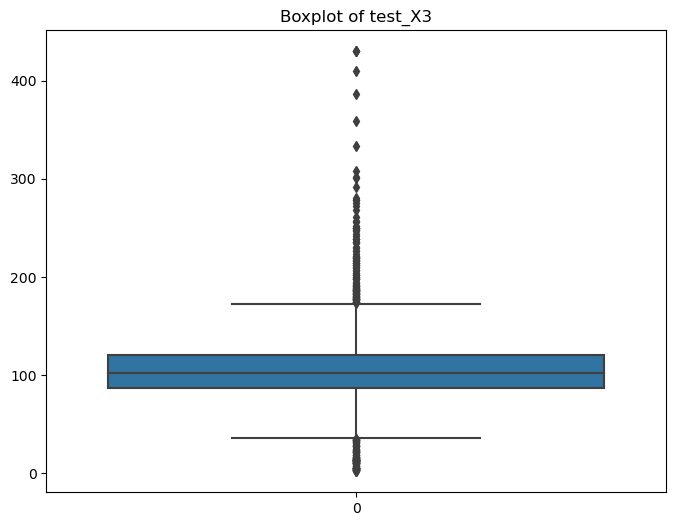

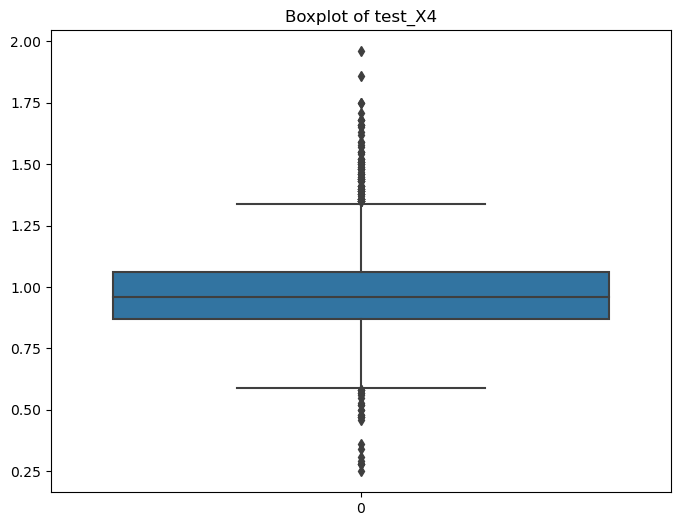

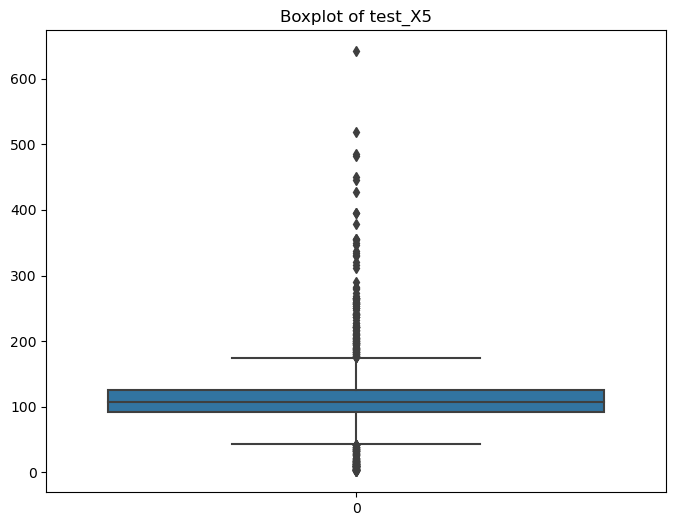

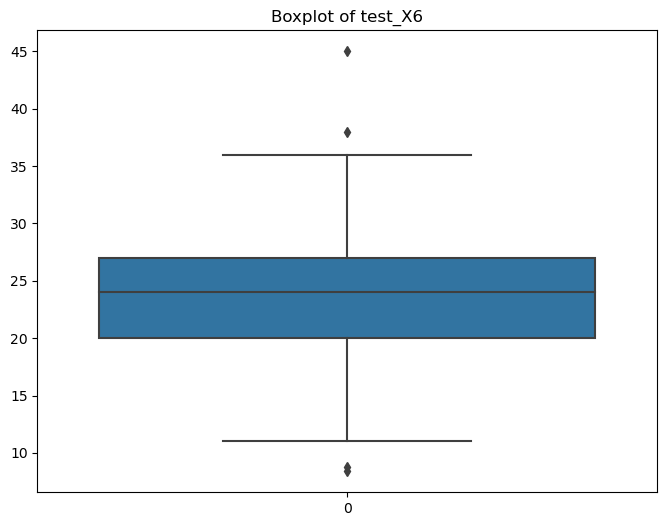

In [12]:
for column in numerical:
    
    plt.figure(figsize=(8,6))
    
    sns.boxplot(data= disease_train[column])
    
    plt.title("Boxplot of " +column)

In [13]:
disease_train.loc[disease_train.age > 100]

,id,age,gender,sick,pregnant,test_X1,test_X2,test_X3,test_X4,test_X5,...,tumor,disorder,medication_A,medication_B,mental_health,mood_stabiliser,surgery,treatment_type1,suspect,target
2459,PA3460,65526,female,no,no,1.5,NaN,132.0,1.02,129.0,...,no,no,no,no,no,no,no,no,no,low_risk
3477,PA4478,455,female,no,no,1.1,2.0,118.0,1.13,104.0,...,no,no,no,no,no,no,no,no,no,low_risk


In [14]:
dtn.loc['null']= disease_train[numerical].isnull().sum()
dtn.loc['%_missing'] = disease_train[numerical].isnull().sum()/4250*100
dtn

,age,test_X1,test_X2,test_X3,test_X4,test_X5,test_X6
count,4250.000000,3839.000000,3007.000000,4034.000000,3858.000000,3863.000000,154.000000
mean,67.374824,7.342463,2.035580,104.919623,0.970846,110.090834,23.325974
std,1004.518821,32.657963,0.920404,35.496255,0.162474,39.837621,5.317032
min,1.000000,0.005000,0.050000,2.000000,0.250000,1.400000,8.400000
25%,37.000000,0.600000,1.600000,87.000000,0.870000,92.000000,20.000000
50%,55.000000,1.500000,1.900000,102.000000,0.960000,107.000000,24.000000
75%,67.000000,3.000000,2.300000,121.000000,1.060000,125.000000,27.000000
max,65526.000000,530.000000,18.000000,430.000000,1.960000,642.000000,45.000000
null,0.000000,411.000000,1243.000000,216.000000,392.000000,387.000000,4096.000000
%_missing,0.000000,9.670588,29.247059,5.082353,9.223529,9.105882,96.376471


In [15]:
L_Risk = disease_train.loc[(disease_train.target.str.strip()=='low_risk')]
M_Risk = disease_train.loc[(disease_train.target.str.strip()=='moderate_risk')]
H_Risk = disease_train.loc[(disease_train.target.str.strip()=='high_risk')]

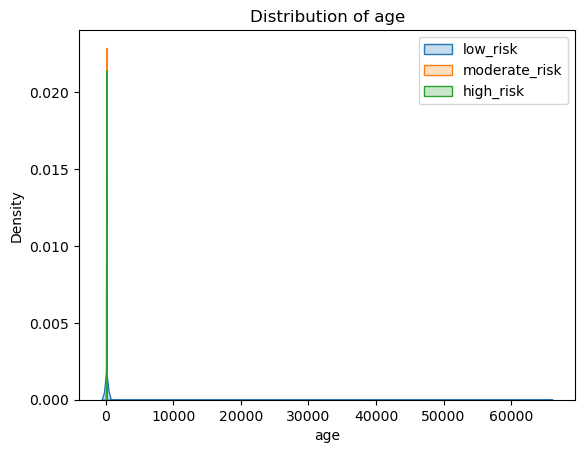

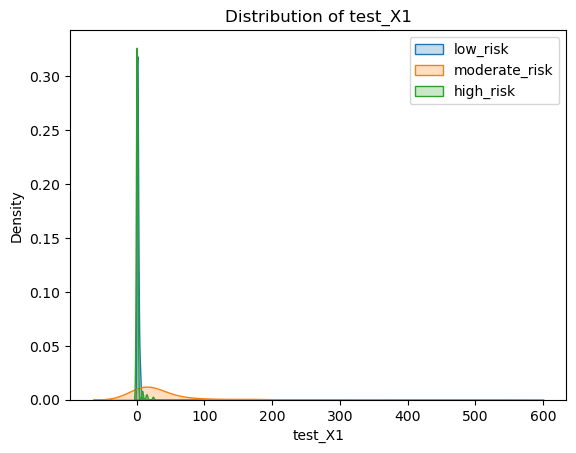

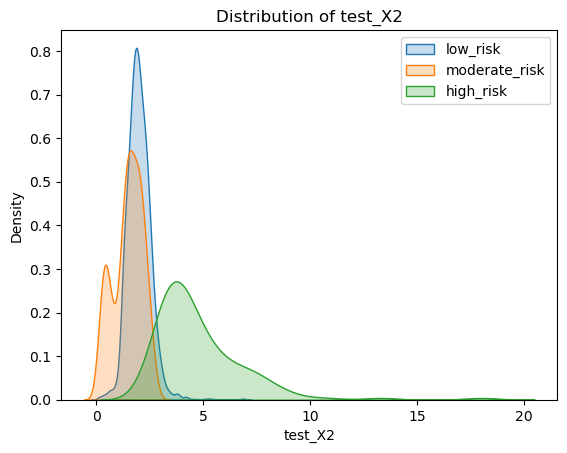

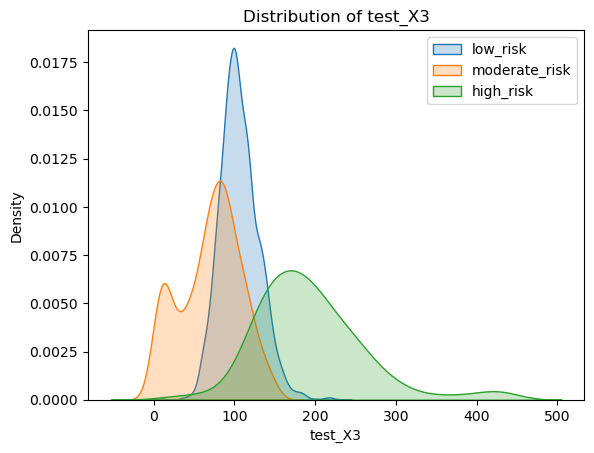

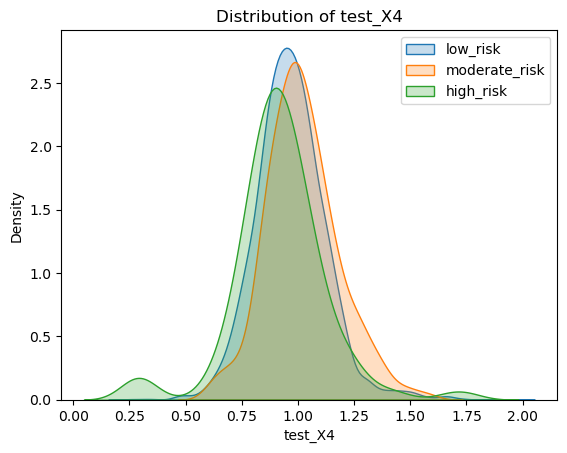

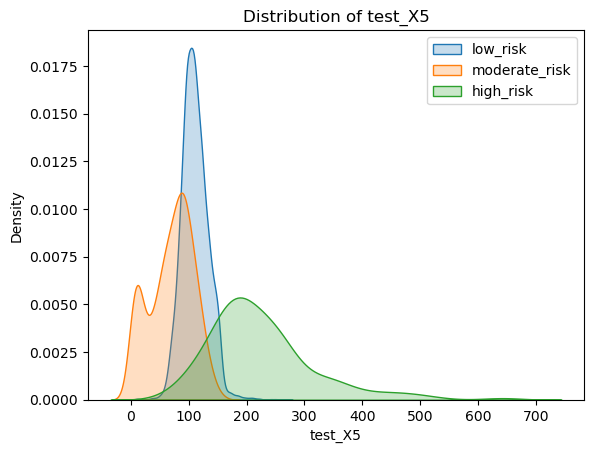

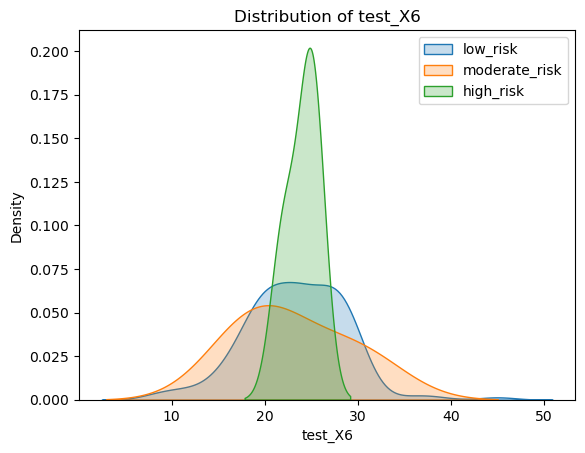

In [16]:
for column in numerical:
    
    plt.figure()
    
    sns.kdeplot(data=L_Risk[column],label="low_risk", fill=True)
    sns.kdeplot(data=M_Risk[column],label="moderate_risk", fill=True)
    sns.kdeplot(data=H_Risk[column],label="high_risk", fill=True)
    
    plt.legend()
    
    plt.title("Distribution of " +column)

## Categorical values

In [17]:
dtc = disease_train[categorical].describe()
dtc.loc['null']= disease_train[categorical].isnull().sum()
dtc

,gender,sick,pregnant,concern_type1,concern_type2,enlargement,tumor,disorder,medication_A,medication_B,mental_health,mood_stabiliser,surgery,treatment_type1,suspect
count,4109,4250,4250,4250,4250,4250,4250,4250,4250,4250,4250,4250,4250,4250,4250
unique,2,2,2,2,2,2,2,1,2,2,2,2,2,2,2
top,female,no,no,no,no,no,no,no,no,no,no,no,no,no,no
freq,2787,4095,4235,4183,3905,4215,4139,4250,3760,4196,4056,4205,4188,4169,3951
null,141,0,0,0,0,0,0,0,0,0,0,0,0,0,0


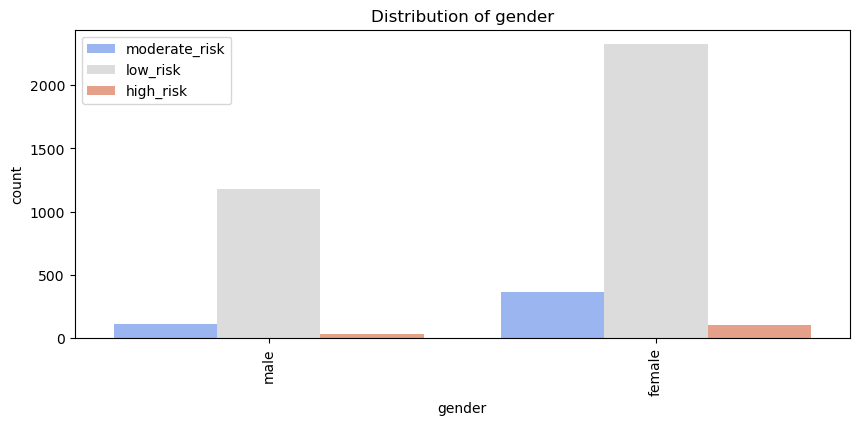

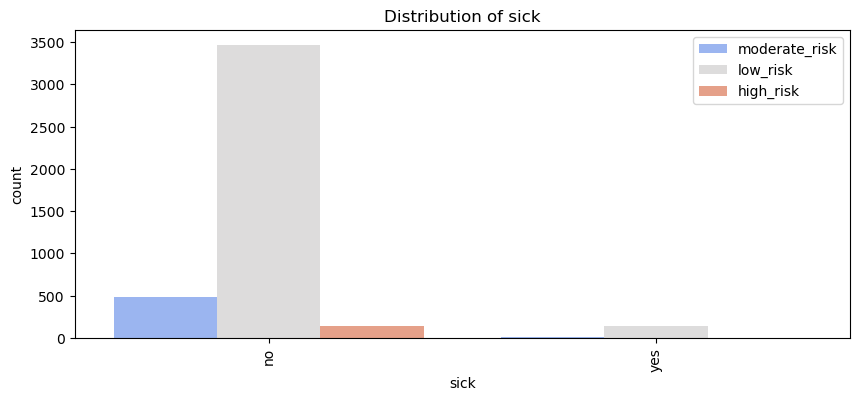

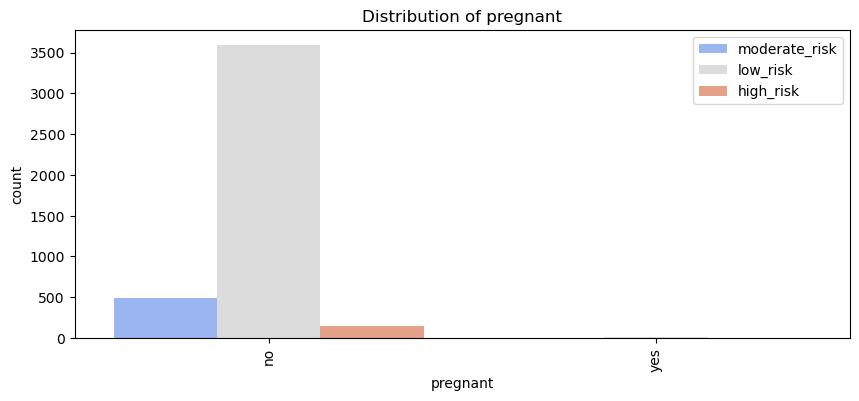

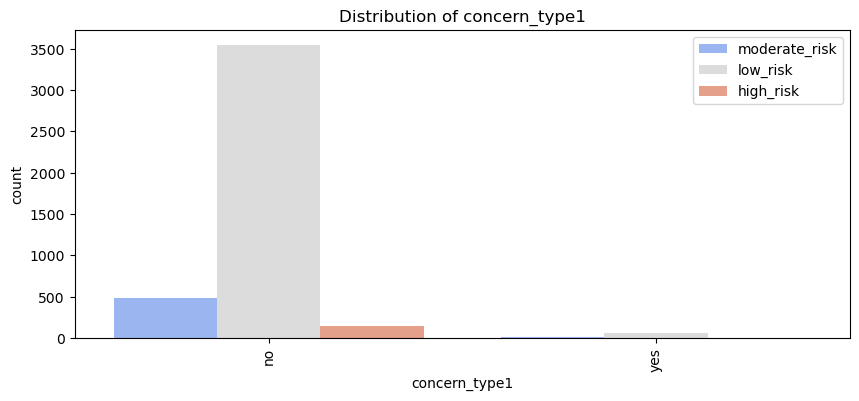

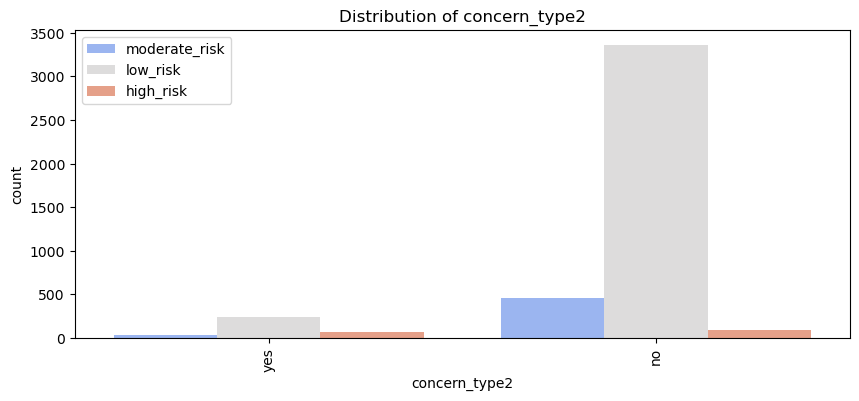

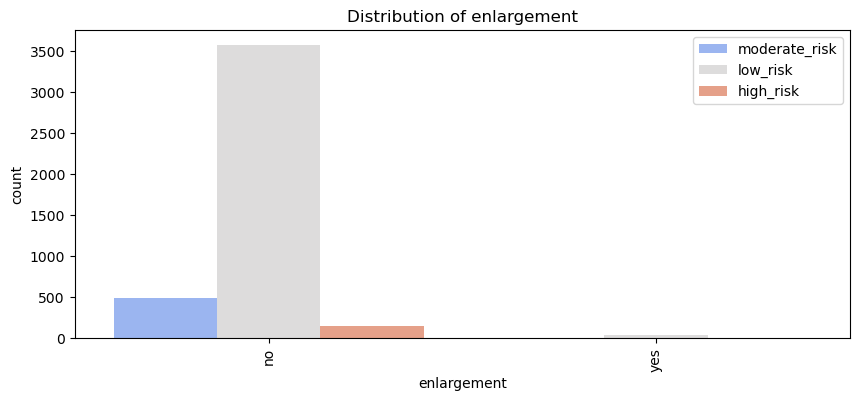

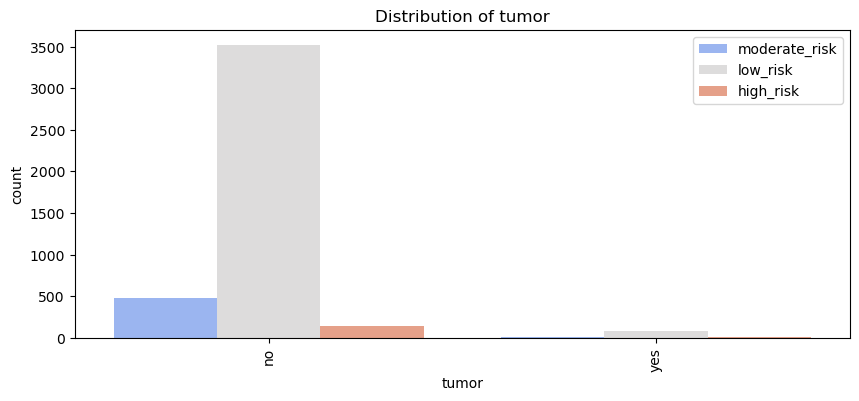

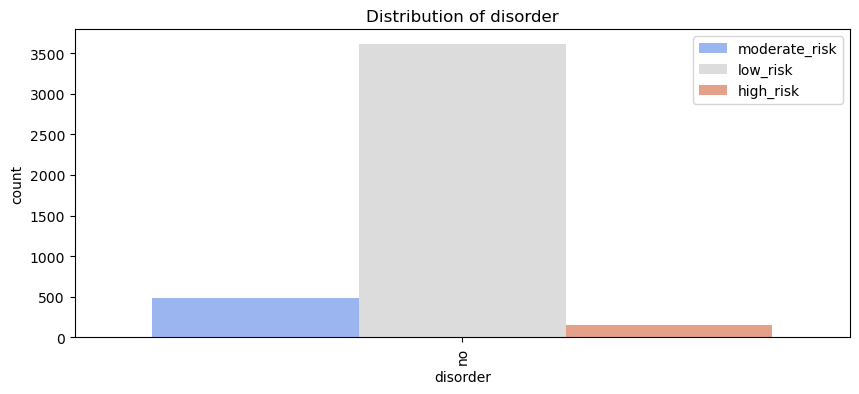

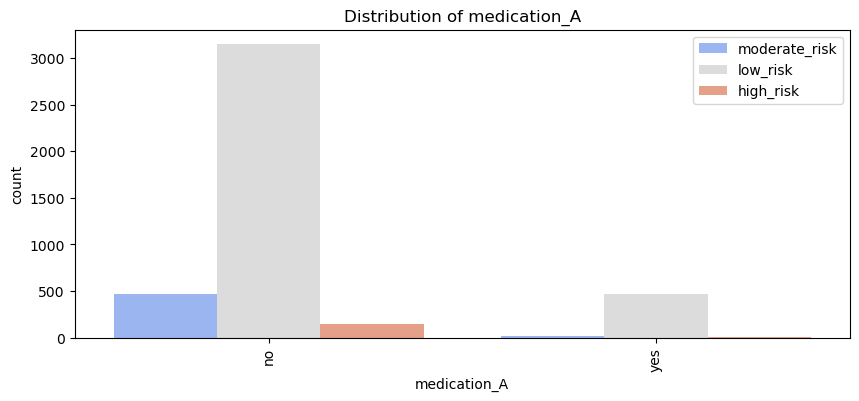

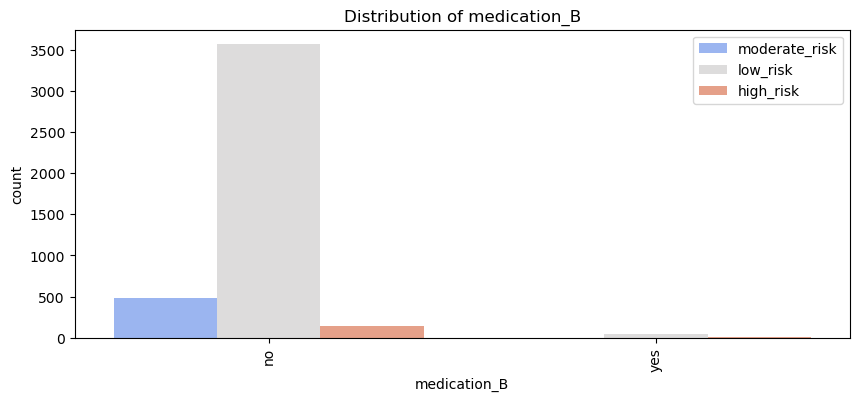

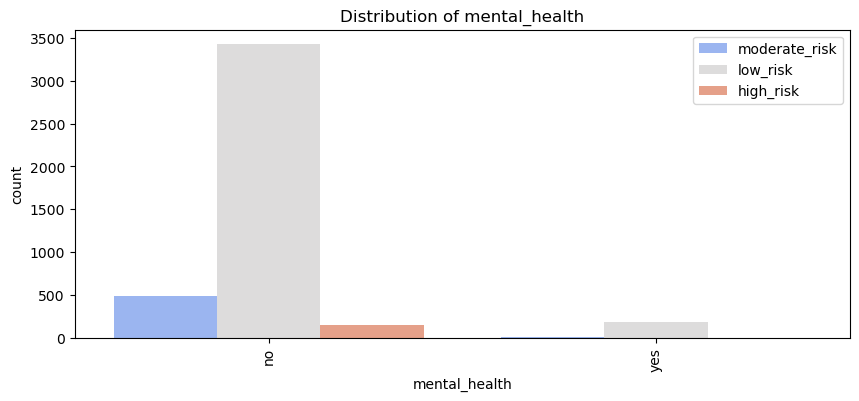

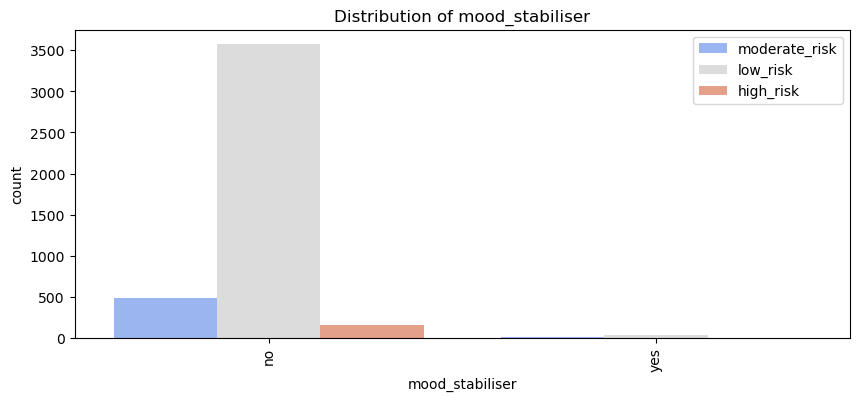

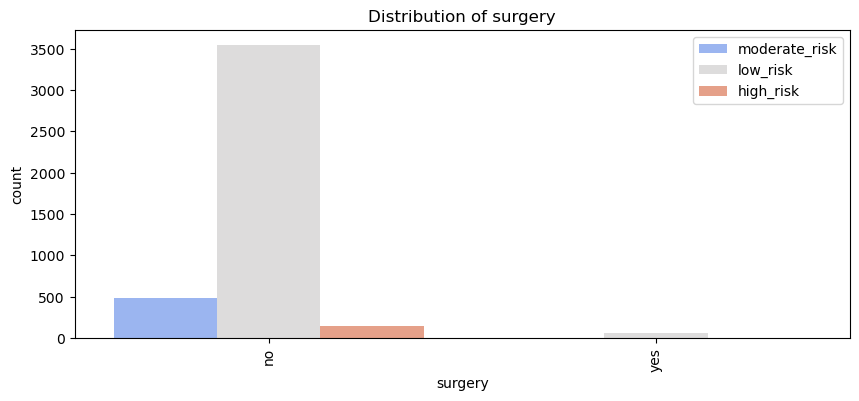

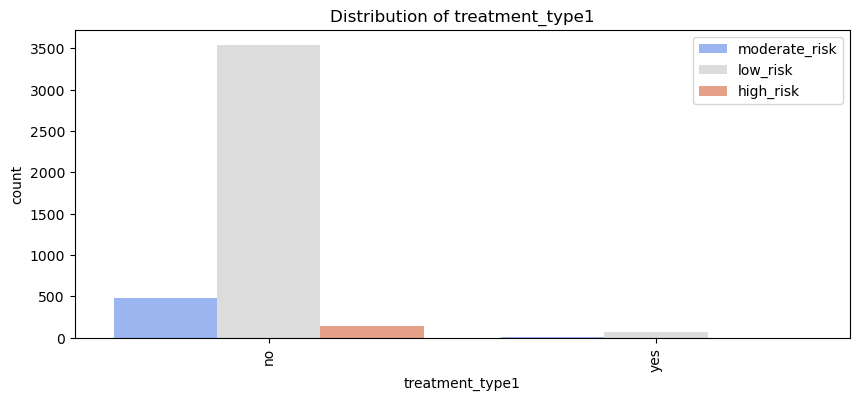

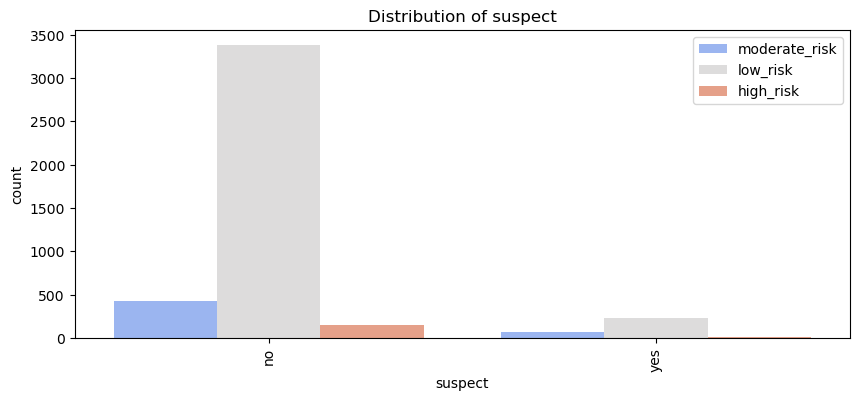

In [18]:
for column in categorical:
    #make sure that plot only takes the two plots below by using the following command
    plt.figure(figsize=(10,4))
    plt.xticks(rotation=90) 
    # produce a plot for each incomelabel so they interlink
    sns.countplot(x=column, hue='target', palette="coolwarm", data=disease_train)
    #include a legent
    plt.legend()
    #include a dynamic title
    plt.title("Distribution of " +column)

In [19]:
disease_train.loc[disease_train.pregnant== 'yes']

,id,age,gender,sick,pregnant,test_X1,test_X2,test_X3,test_X4,test_X5,...,tumor,disorder,medication_A,medication_B,mental_health,mood_stabiliser,surgery,treatment_type1,suspect,target
157,PA1158,25,female,no,yes,0.800,2.8,143.0,1.66,86.0,...,no,no,yes,no,no,no,no,no,no,low_risk
160,PA1161,73,female,no,yes,1.200,1.8,121.0,0.91,134.0,...,no,no,yes,no,no,no,no,no,no,low_risk
630,PA1631,31,female,no,yes,0.440,1.5,75.0,0.92,81.0,...,no,no,yes,no,no,no,no,no,no,low_risk
847,PA1848,31,female,no,yes,0.300,2.1,178.0,1.68,106.0,...,no,no,no,no,no,no,no,no,no,low_risk
1220,PA2221,36,female,no,yes,0.005,NaN,108.0,1.10,99.0,...,no,no,no,no,no,no,no,no,no,low_risk
1566,PA2567,27,female,no,yes,0.360,2.4,114.0,1.00,115.0,...,no,no,no,no,no,no,no,no,no,low_risk
1605,PA2606,41,female,no,yes,0.200,NaN,430.0,1.09,395.0,...,no,no,no,no,no,no,no,no,no,high_risk
1823,PA2824,34,female,no,yes,0.400,2.5,128.0,1.05,122.0,...,yes,no,yes,no,no,no,no,no,no,low_risk
1836,PA2837,20,female,no,yes,NaN,NaN,NaN,NaN,NaN,...,no,no,no,no,no,no,no,no,no,low_risk
2088,PA3089,27,female,no,yes,NaN,NaN,110.0,1.10,100.0,...,no,no,no,no,no,no,no,no,no,low_risk


## 2. Data Cleansing and Pre-processing:
Once we have identify our data we continue by:
Undertaking any cleansing or pre-processing necessary on the dataset.
One criteria used was, to remove any feature/column if 60% values are missing,
constant, or to remove duplicate and highly correlated information. 



In [20]:
disease_train.shape

(4250, 24)

In [21]:
disease_train = disease_train.drop(disease_train[disease_train['age'] > 100].index)
disease_train = disease_train.drop(disease_train[(disease_train['age'] > 45) & (disease_train['pregnant'] == 'yes')].index)
disease_train = disease_train.drop('test_X6', axis=1)
disease_train = disease_train.drop('disorder', axis=1)
disease_train.T

,0,1,2,3,4,5,6,7,8,9,...,4240,4241,4242,4243,4244,4245,4246,4247,4248,4249
id,PA1001,PA1002,PA1003,PA1004,PA1005,PA1006,PA1007,PA1008,PA1009,PA1010,...,PA5241,PA5242,PA5243,PA5244,PA5245,PA5246,PA5247,PA5248,PA5249,PA5250
age,59,48,77,42,38,44,90,69,33,42,...,32,76,67,58,37,29,46,72,94,41
gender,male,female,male,female,female,male,female,female,female,female,...,female,male,male,female,female,male,female,female,female,male
sick,no,no,no,no,no,no,no,no,no,no,...,no,no,no,no,no,no,no,no,no,no
pregnant,no,no,no,no,no,no,no,no,no,no,...,no,no,no,no,no,no,no,no,no,no
test_X1,7.8,1.5,7.3,1.2,0.6,3.0,1.5,6.9,0.1,1.9,...,1.6,0.64,0.2,1.7,1.0,0.5,35.0,3.4,3.9,1.8
test_X2,NaN,2.5,1.2,2.5,1.9,2.0,1.8,NaN,1.7,2.2,...,1.7,1.4,1.9,2.4,2.3,2.3,1.2,2.1,NaN,2.8
test_X3,89.0,101.0,57.0,106.0,95.0,115.0,98.0,109.0,104.0,126.0,...,125.0,101.0,109.0,133.0,89.0,105.0,16.0,88.0,157.0,60.0
test_X4,0.85,0.97,1.28,0.98,NaN,1.1,0.94,1.03,0.8,0.97,...,0.96,0.84,1.03,1.15,0.94,0.86,0.86,0.96,1.02,0.95
test_X5,105.0,104.0,44.0,108.0,NaN,104.0,104.0,106.0,130.0,130.0,...,130.0,120.0,106.0,116.0,95.0,122.0,19.0,92.0,154.0,63.0


## Missing Values

### Numerical

In [22]:
dtn

,age,test_X1,test_X2,test_X3,test_X4,test_X5,test_X6
count,4250.000000,3839.000000,3007.000000,4034.000000,3858.000000,3863.000000,154.000000
mean,67.374824,7.342463,2.035580,104.919623,0.970846,110.090834,23.325974
std,1004.518821,32.657963,0.920404,35.496255,0.162474,39.837621,5.317032
min,1.000000,0.005000,0.050000,2.000000,0.250000,1.400000,8.400000
25%,37.000000,0.600000,1.600000,87.000000,0.870000,92.000000,20.000000
50%,55.000000,1.500000,1.900000,102.000000,0.960000,107.000000,24.000000
75%,67.000000,3.000000,2.300000,121.000000,1.060000,125.000000,27.000000
max,65526.000000,530.000000,18.000000,430.000000,1.960000,642.000000,45.000000
null,0.000000,411.000000,1243.000000,216.000000,392.000000,387.000000,4096.000000
%_missing,0.000000,9.670588,29.247059,5.082353,9.223529,9.105882,96.376471


In [23]:
disease_train.test_X1 = disease_train.test_X1.fillna(disease_train.test_X1.median())

In [24]:
disease_train.test_X2 = disease_train.test_X2.fillna(disease_train.test_X2.median())

In [25]:
disease_train.test_X3 = disease_train.test_X3.fillna(disease_train.test_X3.median())

In [26]:
disease_train.test_X4 = disease_train.test_X4.fillna(disease_train.test_X4.mean())

In [27]:
disease_train.test_X5 = disease_train.test_X5.fillna(disease_train.test_X5.median())

### Categorical

In [28]:
dtc

,gender,sick,pregnant,concern_type1,concern_type2,enlargement,tumor,disorder,medication_A,medication_B,mental_health,mood_stabiliser,surgery,treatment_type1,suspect
count,4109,4250,4250,4250,4250,4250,4250,4250,4250,4250,4250,4250,4250,4250,4250
unique,2,2,2,2,2,2,2,1,2,2,2,2,2,2,2
top,female,no,no,no,no,no,no,no,no,no,no,no,no,no,no
freq,2787,4095,4235,4183,3905,4215,4139,4250,3760,4196,4056,4205,4188,4169,3951
null,141,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [29]:
disease_train.gender = disease_train.gender.fillna('female')

In [30]:
disease_train.isna().sum()

id                 0
age                0
gender             0
sick               0
pregnant           0
test_X1            0
test_X2            0
test_X3            0
test_X4            0
test_X5            0
concern_type1      0
concern_type2      0
enlargement        0
tumor              0
medication_A       0
medication_B       0
mental_health      0
mood_stabiliser    0
surgery            0
treatment_type1    0
suspect            0
target             0
dtype: int64

## Encoding

In [31]:
disease_train = disease_train.replace("no", 0.0)
disease_train 

,id,age,gender,sick,pregnant,test_X1,test_X2,test_X3,test_X4,test_X5,...,enlargement,tumor,medication_A,medication_B,mental_health,mood_stabiliser,surgery,treatment_type1,suspect,target
0,PA1001,59,male,0.0,0.0,7.8,1.9,89.0,0.850000,105.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,moderate_risk
1,PA1002,48,female,0.0,0.0,1.5,2.5,101.0,0.970000,104.0,...,0.0,0.0,yes,0.0,0.0,yes,0.0,0.0,0.0,low_risk
2,PA1003,77,male,0.0,0.0,7.3,1.2,57.0,1.280000,44.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,moderate_risk
3,PA1004,42,female,0.0,0.0,1.2,2.5,106.0,0.980000,108.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low_risk
4,PA1005,38,female,0.0,0.0,0.6,1.9,95.0,0.970808,107.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low_risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4245,PA5246,29,male,0.0,0.0,0.5,2.3,105.0,0.860000,122.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low_risk
4246,PA5247,46,female,0.0,0.0,35.0,1.2,16.0,0.860000,19.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,moderate_risk
4247,PA5248,72,female,0.0,0.0,3.4,2.1,88.0,0.960000,92.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low_risk
4248,PA5249,94,female,0.0,0.0,3.9,1.9,157.0,1.020000,154.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low_risk


In [32]:
disease_train = disease_train.replace("yes", 1.0)
disease_train

,id,age,gender,sick,pregnant,test_X1,test_X2,test_X3,test_X4,test_X5,...,enlargement,tumor,medication_A,medication_B,mental_health,mood_stabiliser,surgery,treatment_type1,suspect,target
0,PA1001,59,male,0.0,0.0,7.8,1.9,89.0,0.850000,105.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,moderate_risk
1,PA1002,48,female,0.0,0.0,1.5,2.5,101.0,0.970000,104.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,low_risk
2,PA1003,77,male,0.0,0.0,7.3,1.2,57.0,1.280000,44.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,moderate_risk
3,PA1004,42,female,0.0,0.0,1.2,2.5,106.0,0.980000,108.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low_risk
4,PA1005,38,female,0.0,0.0,0.6,1.9,95.0,0.970808,107.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low_risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4245,PA5246,29,male,0.0,0.0,0.5,2.3,105.0,0.860000,122.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low_risk
4246,PA5247,46,female,0.0,0.0,35.0,1.2,16.0,0.860000,19.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,moderate_risk
4247,PA5248,72,female,0.0,0.0,3.4,2.1,88.0,0.960000,92.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low_risk
4248,PA5249,94,female,0.0,0.0,3.9,1.9,157.0,1.020000,154.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low_risk


In [33]:
disease_train.head().T

,0,1,2,3,4
id,PA1001,PA1002,PA1003,PA1004,PA1005
age,59,48,77,42,38
gender,male,female,male,female,female
sick,0.0,0.0,0.0,0.0,0.0
pregnant,0.0,0.0,0.0,0.0,0.0
test_X1,7.8,1.5,7.3,1.2,0.6
test_X2,1.9,2.5,1.2,2.5,1.9
test_X3,89.0,101.0,57.0,106.0,95.0
test_X4,0.85,0.97,1.28,0.98,0.970808
test_X5,105.0,104.0,44.0,108.0,107.0


In [34]:
disease_train.gender = disease_train.gender.replace('male', 0.0)
disease_train.gender

0          0.0
1       female
2          0.0
3       female
4       female
         ...  
4245       0.0
4246    female
4247    female
4248    female
4249       0.0
Name: gender, Length: 4247, dtype: object

In [35]:
disease_train.gender = disease_train.gender.replace('female', 1.0)
disease_train.gender

0       0.0
1       1.0
2       0.0
3       1.0
4       1.0
       ... 
4245    0.0
4246    1.0
4247    1.0
4248    1.0
4249    0.0
Name: gender, Length: 4247, dtype: float64

In [36]:
disease_train.head().T

,0,1,2,3,4
id,PA1001,PA1002,PA1003,PA1004,PA1005
age,59,48,77,42,38
gender,0.0,1.0,0.0,1.0,1.0
sick,0.0,0.0,0.0,0.0,0.0
pregnant,0.0,0.0,0.0,0.0,0.0
test_X1,7.8,1.5,7.3,1.2,0.6
test_X2,1.9,2.5,1.2,2.5,1.9
test_X3,89.0,101.0,57.0,106.0,95.0
test_X4,0.85,0.97,1.28,0.98,0.970808
test_X5,105.0,104.0,44.0,108.0,107.0


In [37]:
disease_train2 = disease_train
disease_train2

,id,age,gender,sick,pregnant,test_X1,test_X2,test_X3,test_X4,test_X5,...,enlargement,tumor,medication_A,medication_B,mental_health,mood_stabiliser,surgery,treatment_type1,suspect,target
0,PA1001,59,0.0,0.0,0.0,7.8,1.9,89.0,0.850000,105.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,moderate_risk
1,PA1002,48,1.0,0.0,0.0,1.5,2.5,101.0,0.970000,104.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,low_risk
2,PA1003,77,0.0,0.0,0.0,7.3,1.2,57.0,1.280000,44.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,moderate_risk
3,PA1004,42,1.0,0.0,0.0,1.2,2.5,106.0,0.980000,108.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low_risk
4,PA1005,38,1.0,0.0,0.0,0.6,1.9,95.0,0.970808,107.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low_risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4245,PA5246,29,0.0,0.0,0.0,0.5,2.3,105.0,0.860000,122.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low_risk
4246,PA5247,46,1.0,0.0,0.0,35.0,1.2,16.0,0.860000,19.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,moderate_risk
4247,PA5248,72,1.0,0.0,0.0,3.4,2.1,88.0,0.960000,92.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low_risk
4248,PA5249,94,1.0,0.0,0.0,3.9,1.9,157.0,1.020000,154.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low_risk


## Defining X and y

In [38]:
X = disease_train2[['age', 'gender', 'sick', 'pregnant','test_X1', 'test_X2', 
         'test_X3','test_X4', 'test_X5', 'concern_type1',
               'concern_type2', 'enlargement', 'tumor',
               'medication_A', 'medication_B', 'mental_health',
               'mood_stabiliser', 'surgery', 'treatment_type1', 'suspect']]
X.head()

,age,gender,sick,pregnant,test_X1,test_X2,test_X3,test_X4,test_X5,concern_type1,concern_type2,enlargement,tumor,medication_A,medication_B,mental_health,mood_stabiliser,surgery,treatment_type1,suspect
0,59,0.0,0.0,0.0,7.8,1.9,89.0,0.850000,105.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,48,1.0,0.0,0.0,1.5,2.5,101.0,0.970000,104.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,77,0.0,0.0,0.0,7.3,1.2,57.0,1.280000,44.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,42,1.0,0.0,0.0,1.2,2.5,106.0,0.980000,108.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,38,1.0,0.0,0.0,0.6,1.9,95.0,0.970808,107.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
y = disease_train2.target
y.head()

0    moderate_risk
1         low_risk
2    moderate_risk
3         low_risk
4         low_risk
Name: target, dtype: object

## Feature Selection

In [40]:
obj_df = X.select_dtypes(exclude=['object']).copy()
FS_Cols=obj_df.columns
FS_Cols

Index(['age', 'gender', 'sick', 'pregnant', 'test_X1', 'test_X2', 'test_X3',
       'test_X4', 'test_X5', 'concern_type1', 'concern_type2', 'enlargement',
       'tumor', 'medication_A', 'medication_B', 'mental_health',
       'mood_stabiliser', 'surgery', 'treatment_type1', 'suspect'],
      dtype='object')

In [41]:
Xi = X[FS_Cols]

In [42]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
# configure to select all features
selector = SelectKBest(score_func=mutual_info_classif, k='all')

# transform train input data
Xfs = selector.fit_transform(Xi,y)

In [43]:
#Retrieve the column names for the selected columns
names = Xi.columns.values[selector.get_support()]
#and their scores
scores = selector.scores_[selector.get_support()]
#pair the values together with the zip function
names_scores = list(zip(names, scores))
#Store the information in a data frame
ns_df = pd.DataFrame(data = names_scores, columns=['Feat_names', 'Mutual_info'])
#Sort the dataframe for better visualization
ns_df_sorted = ns_df.sort_values(['Mutual_info', 'Feat_names'], ascending = [False, True])
print(ns_df_sorted)

         Feat_names  Mutual_info
4           test_X1     0.375712
8           test_X5     0.189989
6           test_X3     0.166459
5           test_X2     0.125062
7           test_X4     0.019148
10    concern_type2     0.015955
12            tumor     0.009361
9     concern_type1     0.004798
11      enlargement     0.003305
19          suspect     0.003004
14     medication_B     0.001793
15    mental_health     0.000719
0               age     0.000698
16  mood_stabiliser     0.000641
1            gender     0.000000
13     medication_A     0.000000
3          pregnant     0.000000
2              sick     0.000000
17          surgery     0.000000
18  treatment_type1     0.000000


## Correlation of variables

In [44]:
corr = Xi.corr()
corr

,age,gender,sick,pregnant,test_X1,test_X2,test_X3,test_X4,test_X5,concern_type1,concern_type2,enlargement,tumor,medication_A,medication_B,mental_health,mood_stabiliser,surgery,treatment_type1,suspect
age,1.000000,0.015618,0.081880,-0.067705,-0.026071,-0.113151,-0.023278,-0.069960,0.011509,-0.004775,-0.054389,-0.079179,-0.037059,-0.002568,-0.035848,-0.084179,-0.027442,-0.033903,0.054098,0.020285
gender,0.015618,1.000000,-0.021022,0.038663,0.036739,0.013751,0.105826,0.222298,0.001120,-0.053643,0.067740,0.016283,0.078260,0.076817,0.017289,-0.086738,-0.024796,0.030948,-0.002924,0.069718
sick,0.081880,-0.021022,1.000000,-0.011193,-0.025832,-0.037468,-0.002703,0.016333,-0.016361,-0.004487,-0.034891,-0.017741,-0.000402,-0.038735,-0.022087,-0.036567,-0.007877,-0.013220,-0.027138,0.005338
pregnant,-0.067705,0.038663,-0.011193,1.000000,-0.011319,0.013517,0.059302,0.094980,0.012410,0.025685,0.088154,-0.005242,0.042075,0.017863,-0.006526,-0.012582,-0.005951,-0.007000,-0.008019,-0.015827
test_X1,-0.026071,0.036739,-0.025832,-0.011319,1.000000,-0.176062,-0.335346,0.127766,-0.325789,-0.019743,-0.028215,-0.015567,-0.017271,-0.009247,-0.016956,-0.032092,-0.012301,-0.006022,0.002286,0.043542
test_X2,-0.113151,0.013751,-0.037468,0.013517,-0.176062,1.000000,0.562867,0.089014,0.517378,-0.020997,0.186272,0.012540,0.070003,-0.030865,0.063893,0.019711,0.003790,-0.008218,0.012021,-0.048287
test_X3,-0.023278,0.105826,-0.002703,0.059302,-0.335346,0.562867,1.000000,0.218135,0.820782,-0.020145,0.150701,0.009974,0.017188,0.135166,0.011426,0.015778,-0.021147,0.000369,-0.021443,-0.022258
test_X4,-0.069960,0.222298,0.016333,0.094980,0.127766,0.089014,0.218135,1.000000,-0.277171,-0.050939,0.050144,0.043279,0.041151,0.051074,0.031657,0.001347,0.000648,0.030865,0.012995,0.038140
test_X5,0.011509,0.001120,-0.016361,0.012410,-0.325789,0.517378,0.820782,-0.277171,1.000000,0.006831,0.127909,-0.011997,0.002219,0.094075,-0.010687,0.011240,-0.021487,-0.011684,-0.023552,-0.038610
concern_type1,-0.004775,-0.053643,-0.004487,0.025685,-0.019743,-0.020997,-0.020145,-0.050939,0.006831,1.000000,-0.030729,0.009361,-0.020741,0.031291,-0.014368,-0.027699,-0.013102,0.016100,-0.017654,-0.005296


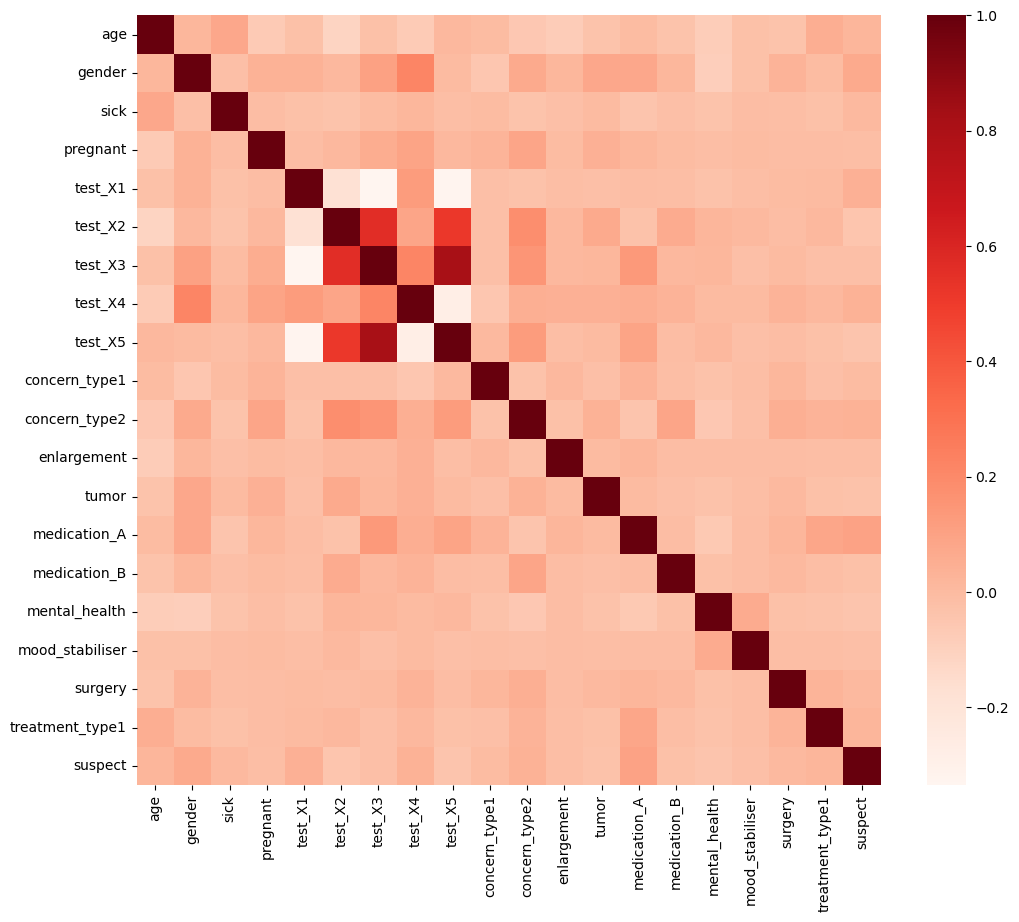

In [45]:
#Using Pearson Correlation
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=False, cmap=plt.cm.Reds)
plt.show()

In [46]:
disease_train3 = disease_train2[['id', 'age', 'sick', 'pregnant','test_X1',
                                 'test_X2','test_X3','test_X4', 'test_X5',
                                 'concern_type2','medication_B','mood_stabiliser',
                                 'treatment_type1', 'suspect', 'target']]
disease_train3 

,id,age,sick,pregnant,test_X1,test_X2,test_X3,test_X4,test_X5,concern_type2,medication_B,mood_stabiliser,treatment_type1,suspect,target
0,PA1001,59,0.0,0.0,7.8,1.9,89.0,0.850000,105.0,1.0,0.0,0.0,0.0,0.0,moderate_risk
1,PA1002,48,0.0,0.0,1.5,2.5,101.0,0.970000,104.0,0.0,0.0,1.0,0.0,0.0,low_risk
2,PA1003,77,0.0,0.0,7.3,1.2,57.0,1.280000,44.0,0.0,0.0,0.0,0.0,0.0,moderate_risk
3,PA1004,42,0.0,0.0,1.2,2.5,106.0,0.980000,108.0,0.0,0.0,0.0,0.0,0.0,low_risk
4,PA1005,38,0.0,0.0,0.6,1.9,95.0,0.970808,107.0,0.0,0.0,0.0,0.0,0.0,low_risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4245,PA5246,29,0.0,0.0,0.5,2.3,105.0,0.860000,122.0,0.0,0.0,0.0,0.0,0.0,low_risk
4246,PA5247,46,0.0,0.0,35.0,1.2,16.0,0.860000,19.0,1.0,0.0,0.0,0.0,0.0,moderate_risk
4247,PA5248,72,0.0,0.0,3.4,2.1,88.0,0.960000,92.0,0.0,0.0,0.0,0.0,0.0,low_risk
4248,PA5249,94,0.0,0.0,3.9,1.9,157.0,1.020000,154.0,0.0,0.0,0.0,0.0,0.0,low_risk


## Defining the X of the subset

In [47]:
X3 = disease_train3[[ 'age', 'sick', 'pregnant','test_X1',
                      'test_X2','test_X3','test_X4', 'test_X5',
                        'concern_type2','medication_B','mood_stabiliser',
                        'treatment_type1', 'suspect']]
X3

,age,sick,pregnant,test_X1,test_X2,test_X3,test_X4,test_X5,concern_type2,medication_B,mood_stabiliser,treatment_type1,suspect
0,59,0.0,0.0,7.8,1.9,89.0,0.850000,105.0,1.0,0.0,0.0,0.0,0.0
1,48,0.0,0.0,1.5,2.5,101.0,0.970000,104.0,0.0,0.0,1.0,0.0,0.0
2,77,0.0,0.0,7.3,1.2,57.0,1.280000,44.0,0.0,0.0,0.0,0.0,0.0
3,42,0.0,0.0,1.2,2.5,106.0,0.980000,108.0,0.0,0.0,0.0,0.0,0.0
4,38,0.0,0.0,0.6,1.9,95.0,0.970808,107.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4245,29,0.0,0.0,0.5,2.3,105.0,0.860000,122.0,0.0,0.0,0.0,0.0,0.0
4246,46,0.0,0.0,35.0,1.2,16.0,0.860000,19.0,1.0,0.0,0.0,0.0,0.0
4247,72,0.0,0.0,3.4,2.1,88.0,0.960000,92.0,0.0,0.0,0.0,0.0,0.0
4248,94,0.0,0.0,3.9,1.9,157.0,1.020000,154.0,0.0,0.0,0.0,0.0,0.0


## 3. Supervised Model Training, Tuning, and Evaluation:
- We split the data into a training set and a validation set once cleansing is done.
- Use toolkits and libraries to train models (e.g. k-NN, Decision Tree,
Random Forest, SVM, etc.) from the training set to
build the health condition Classifier. We make sure to perform adequate parameter
tuning for each model. 
- We evaluate the performance of the models on the test/validation set.
- We used appropriate tools to clearly illustrate and identify the features that were
deemed most crucial or had the most significant impact on decision-making within
the best-performing model.
- We produce the predicted label for your best classification model on the separate test
set that we have (predictedTarget-1.csv).
 


# Data splitting

## First version (X)

In [48]:
#from sklearn.model_selection import train_test_split

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

#y_train

In [49]:
print("Original set description \n", X.describe())

Original set description 
                age       gender         sick     pregnant      test_X1  \
count  4247.000000  4247.000000  4247.000000  4247.000000  4247.000000   
mean     51.869320     0.688721     0.036496     0.003296     6.781355   
std      18.699765     0.463071     0.187544     0.057327    31.096963   
min       1.000000     0.000000     0.000000     0.000000     0.005000   
25%      37.000000     0.000000     0.000000     0.000000     0.700000   
50%      55.000000     1.000000     0.000000     0.000000     1.500000   
75%      67.000000     1.000000     0.000000     0.000000     2.700000   
max      97.000000     1.000000     1.000000     1.000000   530.000000   

           test_X2      test_X3      test_X4      test_X5  concern_type1  \
count  4247.000000  4247.000000  4247.000000  4247.000000    4247.000000   
mean      1.995995   104.757890     0.970808   109.800539       0.015776   
std       0.776879    34.596398     0.154829    38.000875       0.124622   
mi

In [50]:
from sklearn.model_selection import train_test_split

X_part1, X_test, y_part1, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

print("Part 1 set description \n",X_part1.describe())
print("Test set description \n",X_test.describe())

Part 1 set description 
                age       gender         sick     pregnant      test_X1  \
count  3397.000000  3397.000000  3397.000000  3397.000000  3397.000000   
mean     51.676185     0.689726     0.035620     0.003238     6.782576   
std      18.769272     0.462674     0.185367     0.056821    31.889168   
min       1.000000     0.000000     0.000000     0.000000     0.005000   
25%      37.000000     0.000000     0.000000     0.000000     0.700000   
50%      54.000000     1.000000     0.000000     0.000000     1.500000   
75%      67.000000     1.000000     0.000000     0.000000     2.700000   
max      97.000000     1.000000     1.000000     1.000000   530.000000   

           test_X2      test_X3      test_X4      test_X5  concern_type1  \
count  3397.000000  3397.000000  3397.000000  3397.000000    3397.000000   
mean      2.001469   104.824775     0.971114   109.878611       0.016191   
std       0.785126    35.415192     0.154345    38.687857       0.126227   
min 

In [51]:
X_train, X_val, y_train, y_val = train_test_split(X_part1, y_part1, test_size=0.2, random_state=43)

print("Train set description \n", X_train.describe())
print("Validation set description \n",X_val.describe())

Train set description 
                age       gender         sick     pregnant      test_X1  \
count  2717.000000  2717.000000  2717.000000  2717.000000  2717.000000   
mean     51.718808     0.691940     0.036069     0.004049     6.906590   
std      18.706212     0.461777     0.186497     0.063511    31.936478   
min       1.000000     0.000000     0.000000     0.000000     0.005000   
25%      37.000000     0.000000     0.000000     0.000000     0.700000   
50%      54.000000     1.000000     0.000000     0.000000     1.500000   
75%      67.000000     1.000000     0.000000     0.000000     2.700000   
max      97.000000     1.000000     1.000000     1.000000   530.000000   

           test_X2      test_X3      test_X4      test_X5  concern_type1  \
count  2717.000000  2717.000000  2717.000000  2717.000000    2717.000000   
mean      1.999871   104.423025     0.972006   109.560596       0.016194   
std       0.776620    34.900185     0.156172    38.610960       0.126246   
min  

## Second version (X3)

In [52]:
#from sklearn.model_selection import train_test_split

#X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y, test_size=0.2, random_state=43)

#y3_train

In [53]:
print("Original set description \n", X3.describe())

Original set description 
                age         sick     pregnant      test_X1      test_X2  \
count  4247.000000  4247.000000  4247.000000  4247.000000  4247.000000   
mean     51.869320     0.036496     0.003296     6.781355     1.995995   
std      18.699765     0.187544     0.057327    31.096963     0.776879   
min       1.000000     0.000000     0.000000     0.005000     0.050000   
25%      37.000000     0.000000     0.000000     0.700000     1.700000   
50%      55.000000     0.000000     0.000000     1.500000     1.900000   
75%      67.000000     0.000000     0.000000     2.700000     2.100000   
max      97.000000     1.000000     1.000000   530.000000    18.000000   

           test_X3      test_X4      test_X5  concern_type2  medication_B  \
count  4247.000000  4247.000000  4247.000000    4247.000000   4247.000000   
mean    104.757890     0.970808   109.800539       0.081234      0.012715   
std      34.596398     0.154829    38.000875       0.273226      0.112054  

In [54]:
from sklearn.model_selection import train_test_split

X3_part1, X3_test, y3_part1, y3_test = train_test_split(X3, y, test_size=0.2, random_state=40)

print("Part 1 set description \n",X3_part1.describe())
print("Test set description \n",X3_test.describe())

Part 1 set description 
                age         sick     pregnant      test_X1      test_X2  \
count  3397.000000  3397.000000  3397.000000  3397.000000  3397.000000   
mean     51.676185     0.035620     0.003238     6.782576     2.001469   
std      18.769272     0.185367     0.056821    31.889168     0.785126   
min       1.000000     0.000000     0.000000     0.005000     0.050000   
25%      37.000000     0.000000     0.000000     0.700000     1.700000   
50%      54.000000     0.000000     0.000000     1.500000     1.900000   
75%      67.000000     0.000000     0.000000     2.700000     2.100000   
max      97.000000     1.000000     1.000000   530.000000    18.000000   

           test_X3      test_X4      test_X5  concern_type2  medication_B  \
count  3397.000000  3397.000000  3397.000000    3397.000000   3397.000000   
mean    104.824775     0.971114   109.878611       0.079482      0.012953   
std      35.415192     0.154345    38.687857       0.270529      0.113087   


In [55]:
X3_train, X3_val, y3_train, y3_val = train_test_split(X3_part1, y3_part1, test_size=0.2, random_state=43)

print("Train set description \n", X3_train.describe())
print("Validation set description \n",X3_val.describe())

Train set description 
                age         sick     pregnant      test_X1      test_X2  \
count  2717.000000  2717.000000  2717.000000  2717.000000  2717.000000   
mean     51.718808     0.036069     0.004049     6.906590     1.999871   
std      18.706212     0.186497     0.063511    31.936478     0.776620   
min       1.000000     0.000000     0.000000     0.005000     0.050000   
25%      37.000000     0.000000     0.000000     0.700000     1.800000   
50%      54.000000     0.000000     0.000000     1.500000     1.900000   
75%      67.000000     0.000000     0.000000     2.700000     2.200000   
max      97.000000     1.000000     1.000000   530.000000    18.000000   

           test_X3      test_X4      test_X5  concern_type2  medication_B  \
count  2717.000000  2717.000000  2717.000000    2717.000000   2717.000000   
mean    104.423025     0.972006   109.560596       0.078395      0.013986   
std      34.900185     0.156172    38.610960       0.268842      0.117454   
m

## Outlier detection (X)

In [56]:
#Designate the continuous input features as train_OL_X
train_OL_X= X_train[['age','test_X1', 'test_X2', 
         'test_X3','test_X4', 'test_X5']]
train_OL_X.shape

(2717, 6)

In [57]:
#import the implementation of this algorihm from sklearn
from sklearn.cluster import DBSCAN

#Use the algorithm for outlier detection, the retun in clusters will show the membership of each point
#Any point labelled as -1 is an outlier

outlier_detection = DBSCAN(min_samples = 3, eps = 10)
clusters = outlier_detection.fit_predict(train_OL_X)

#Count total number of outliers as count of those labelled as -1
TotalOutliers=list(clusters).count(-1)
#print (clusters)
print("Total number of outliers identified is: ",TotalOutliers)

Total number of outliers identified is:  299


In [58]:
mask = clusters != -1
# Apply mask to y and check shape
y1= y_train[mask]
print (y1.shape)

#Apply mask to X and check shape 
X1= train_OL_X[mask]
print(X1.shape)

(2418,)
(2418, 6)


In [59]:
#import the implementation of this algorihm from sklearn
from sklearn.ensemble import IsolationForest

#Use the algorithm for outlier detection, then use it to predict each point
#Any point labelled as -1 is an outlier
clf = IsolationForest(max_samples=3397, random_state = 1, contamination= 0.01)
preds = clf.fit_predict(train_OL_X)
#print(preds)
totalOutliers=0
for pred in preds:
    if pred == -1:
        totalOutliers=totalOutliers+1
print("Total number of outliers identified is: ",totalOutliers)

C:\Users\mse98\anaconda3\Lib\site-packages\sklearn\ensemble\_iforest.py:288: UserWarning: max_samples (3397) is greater than the total number of samples (2717). max_samples will be set to n_samples for estimation.
  warn(
C:\Users\mse98\anaconda3\Lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Total number of outliers identified is:  28


In [60]:
# select all rows that are not outliers and create a boolean mask
mask = preds != -1
# Apply mask to y and check shape
y2= y_train[mask]
print (y2.shape)

#Apply mask to X and check shape 
X2=train_OL_X[mask]
print(X2.shape)

(2689,)
(2689, 6)


## Outlier detection (X3)

In [61]:
#Designate the continuous input features as train_OL_X
train_OL_X3= X3_train[['age','test_X1', 'test_X2', 
         'test_X3','test_X4', 'test_X5']]
train_OL_X3.shape

(2717, 6)

In [62]:
#import the implementation of this algorihm from sklearn
from sklearn.cluster import DBSCAN

#Use the algorithm for outlier detection, the retun in clusters will show the membership of each point
#Any point labelled as -1 is an outlier

outlier_detection = DBSCAN(min_samples = 3, eps = 10)
clusters = outlier_detection.fit_predict(train_OL_X3)

#Count total number of outliers as count of those labelled as -1
TotalOutliers=list(clusters).count(-1)
#print (clusters)
print("Total number of outliers identified is: ",TotalOutliers)

Total number of outliers identified is:  299


In [63]:
mask = clusters != -1
# Apply mask to y and check shape
y4= y3_train[mask]
print (y4.shape)

#Apply mask to X and check shape 
X4= train_OL_X3[mask]
print(X4.shape)

(2418,)
(2418, 6)


In [64]:
#import the implementation of this algorihm from sklearn
from sklearn.ensemble import IsolationForest

#Use the algorithm for outlier detection, then use it to predict each point
#Any point labelled as -1 is an outlier
clf = IsolationForest(max_samples=2717, random_state = 1, contamination= 0.01)
preds = clf.fit_predict(train_OL_X3)
#print(preds)
totalOutliers=0
for pred in preds:
    if pred == -1:
        totalOutliers=totalOutliers+1
print("Total number of outliers identified is: ",totalOutliers)

Total number of outliers identified is:  28


C:\Users\mse98\anaconda3\Lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


In [65]:
# select all rows that are not outliers and create a boolean mask
mask = preds != -1
# Apply mask to y and check shape
y5= y3_train[mask]
print (y5.shape)

#Apply mask to X and check shape 
X5=train_OL_X3[mask]
print(X5.shape)

(2689,)
(2689, 6)


## Balancing data (X)

In [66]:
y_train.value_counts()

low_risk         2304
moderate_risk     321
high_risk          92
Name: target, dtype: int64

In [67]:
from imblearn.over_sampling import SMOTE

# Count the occurrences of each class in the training set
#class_counts = y_train.value_counts()
class_counts = np.unique(y_train, return_counts=True)

# Display the class counts before balancing
print("Class Counts Before Balancing:")
print(class_counts)

# Apply SMOTE to the training set
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Count the occurrences of each class after balancing
balanced_class_counts = np.unique(y_train_balanced, return_counts=True)

# Display the class counts after balancing
print("\nClass Counts After Balancing:")
print(balanced_class_counts)

Class Counts Before Balancing:
(array(['high_risk', 'low_risk', 'moderate_risk'], dtype=object), array([  92, 2304,  321], dtype=int64))

Class Counts After Balancing:
(array(['high_risk', 'low_risk', 'moderate_risk'], dtype=object), array([2304, 2304, 2304], dtype=int64))


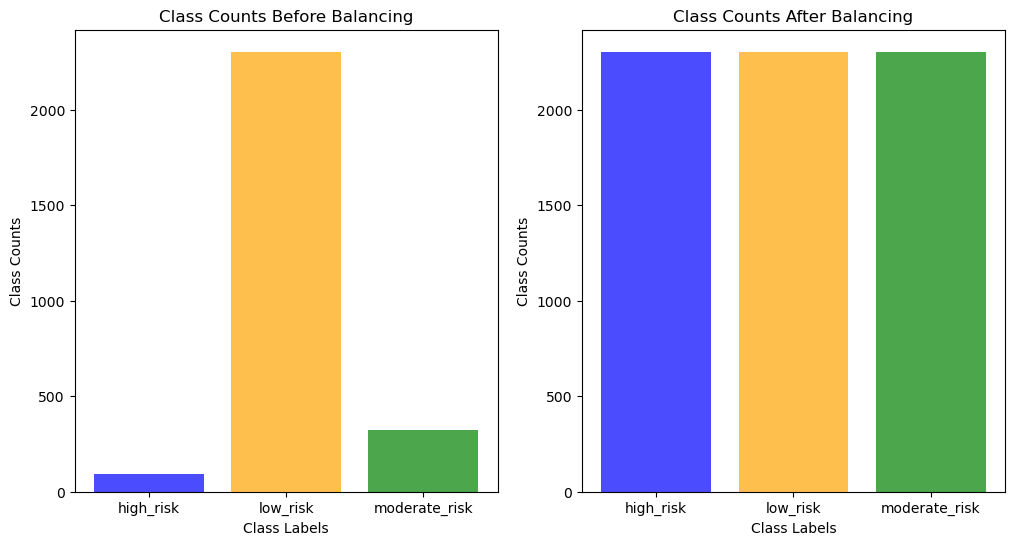

In [68]:
import matplotlib.pyplot as plt

class_labels_before, counts_before = class_counts[0], class_counts[1]
class_labels_after, counts_after = balanced_class_counts[0], balanced_class_counts[1]

# Specify colors for each class
colors_before = ['blue', 'orange', 'green']  # Replace with your desired colors
colors_after = ['blue', 'orange', 'green']  # Replace with your desired colors

# Plotting class counts before and after balancing
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.bar(class_labels_before, counts_before, color=colors_before, alpha=0.7)
ax1.set_title('Class Counts Before Balancing')
ax1.set_xlabel('Class Labels')
ax1.set_ylabel('Class Counts')

ax2.bar(class_labels_after, counts_after, color=colors_after, alpha=0.7)
ax2.set_title('Class Counts After Balancing')
ax2.set_xlabel('Class Labels')
ax2.set_ylabel('Class Counts')

plt.show()

## Balancing data (X3)

In [69]:
y3_train.value_counts()

low_risk         2304
moderate_risk     321
high_risk          92
Name: target, dtype: int64

In [70]:
from imblearn.over_sampling import SMOTE

# Count the occurrences of each class in the training set
#class_counts = y_train.value_counts()
class_counts3 = np.unique(y3_train, return_counts=True)

# Display the class counts before balancing
print("Class Counts Before Balancing:")
print(class_counts3)

# Apply SMOTE to the training set
smote = SMOTE(random_state=43)
X3_train_balanced, y3_train_balanced = smote.fit_resample(X3_train, y3_train)

# Count the occurrences of each class after balancing
balanced_class_counts3 = np.unique(y3_train_balanced, return_counts=True)

# Display the class counts after balancing
print("\nClass Counts After Balancing:")
print(balanced_class_counts3)


Class Counts Before Balancing:
(array(['high_risk', 'low_risk', 'moderate_risk'], dtype=object), array([  92, 2304,  321], dtype=int64))

Class Counts After Balancing:
(array(['high_risk', 'low_risk', 'moderate_risk'], dtype=object), array([2304, 2304, 2304], dtype=int64))


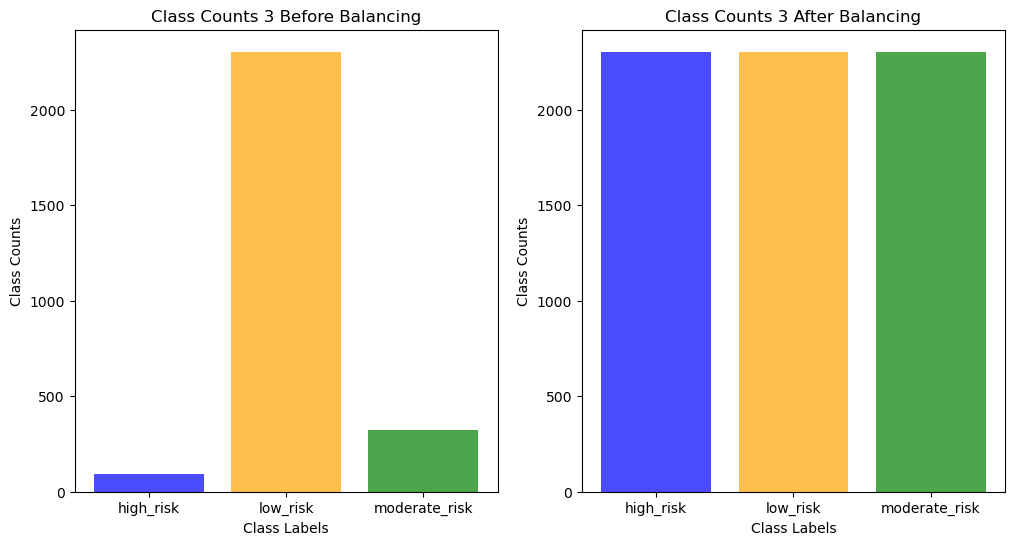

In [71]:
import matplotlib.pyplot as plt

class_labels_before_3, counts_before_3 = class_counts3[0], class_counts3[1]
class_labels_after_3, counts_after_3 = balanced_class_counts3[0], balanced_class_counts3[1]

# Specify colors for each class
colors_before_3 = ['blue', 'orange', 'green']  # Replace with your desired colors
colors_after_3 = ['blue', 'orange', 'green']  # Replace with your desired colors

# Plotting class counts before and after balancing
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.bar(class_labels_before_3, counts_before_3, color=colors_before_3, alpha=0.7)
ax1.set_title('Class Counts 3 Before Balancing')
ax1.set_xlabel('Class Labels')
ax1.set_ylabel('Class Counts')

ax2.bar(class_labels_after_3, counts_after_3, color=colors_after_3, alpha=0.7)
ax2.set_title('Class Counts 3 After Balancing')
ax2.set_xlabel('Class Labels')
ax2.set_ylabel('Class Counts')

plt.show()

# Supervised model training

## k-NN

### For balanced data (X)

In [72]:
from sklearn.neighbors import KNeighborsClassifier

knn_classifier = KNeighborsClassifier(n_neighbors=3)

# Train the classifier on the training data
knn_classifier.fit(X_train_balanced, y_train_balanced)

KNeighborsClassifier(n_neighbors=3)

In [73]:
# Make predictions on the test data
y_pred = knn_classifier.predict(X_test)

### Grid Search Cross Validation

In [74]:
from sklearn.model_selection import GridSearchCV

#make a dictionary, where the parameter we want to set, and the range of values we want to cross-validate over
#in this example I am going to set the k parameter in kNN, where I am testing between 1 to 7.
parameters = {
    "n_neighbors" : [1,3,5,7]
}

clf = GridSearchCV(knn_classifier,param_grid=parameters)
clf.fit(X_train, y_train)

#here we can see the best parameter was for n_neighbors
print('Best parameter for n_neighbors', clf.best_params_)

#collect predictions on test data
y_hat = clf.predict(X_test)


#calculate the score - accuracy / error or other metrics.
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_hat)
print('accuracy', accuracy)

Best parameter for n_neighbors {'n_neighbors': 3}
accuracy 0.9423529411764706


### Validation set

In [75]:
accuracies = []
# Test for number of neighbours 1 to 20
for  i in range(1,20):
    #build classifier with our current parameter.
    clf_knn = KNeighborsClassifier(n_neighbors=i,weights='uniform')
          
    #fit our parameterised model to the cross-validated data.
    clf_knn.fit(X_train, y_train)
        
    #obtain predictions on the cv test set.
    y_hat_cv = clf_knn.predict(X_val)


    #append the accuracies to the list of all of them.
    accuracies.append(accuracy_score(y_val, y_hat_cv))
    print('Neighbours:',i, '\ Accuracy:',round(accuracies[i-1],2))
    
#print(accuracies)

# pick the best parameter as the index of the argmax in the accuracies (-1 to account for indexing starting at 0)
#argmax returns the indices of the maximum values along an axis. 
best_paramater = np.argmax(accuracies)+1
print('Best parameter is:',best_paramater)

Neighbours: 1 \ Accuracy: 0.94
Neighbours: 2 \ Accuracy: 0.92
Neighbours: 3 \ Accuracy: 0.94
Neighbours: 4 \ Accuracy: 0.93
Neighbours: 5 \ Accuracy: 0.93
Neighbours: 6 \ Accuracy: 0.93
Neighbours: 7 \ Accuracy: 0.93
Neighbours: 8 \ Accuracy: 0.92
Neighbours: 9 \ Accuracy: 0.93
Neighbours: 10 \ Accuracy: 0.92
Neighbours: 11 \ Accuracy: 0.92
Neighbours: 12 \ Accuracy: 0.92
Neighbours: 13 \ Accuracy: 0.92
Neighbours: 14 \ Accuracy: 0.91
Neighbours: 15 \ Accuracy: 0.91
Neighbours: 16 \ Accuracy: 0.91
Neighbours: 17 \ Accuracy: 0.91
Neighbours: 18 \ Accuracy: 0.91
Neighbours: 19 \ Accuracy: 0.91
Best parameter is: 1


In [76]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# test set (X_test, y_test)
y_pred = knn_classifier.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Evaluate precision
precision = precision_score(y_test, y_pred, average='weighted')

# Evaluate recall
recall = recall_score(y_test, y_pred, average='weighted')

# Print the results
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

Accuracy: 0.91
Precision: 0.94
Recall: 0.91


In [77]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

               precision    recall  f1-score   support

    high_risk       0.32      0.81      0.46        27
     low_risk       0.97      0.92      0.95       730
moderate_risk       0.86      0.83      0.84        93

     accuracy                           0.91       850
    macro avg       0.72      0.85      0.75       850
 weighted avg       0.94      0.91      0.92       850



### Check for overfitting and underfitting

In [78]:
print('Training set score: {:.4f}'.format(knn_classifier.score(X_train_balanced, y_train_balanced)))
print('Validation set score: {:.4f}'.format(knn_classifier.score(X_val, y_val)))
print('Test set score: {:.4f}'.format(knn_classifier.score(X_test, y_test)))

Training set score: 0.9829
Validation set score: 0.8956
Test set score: 0.9071


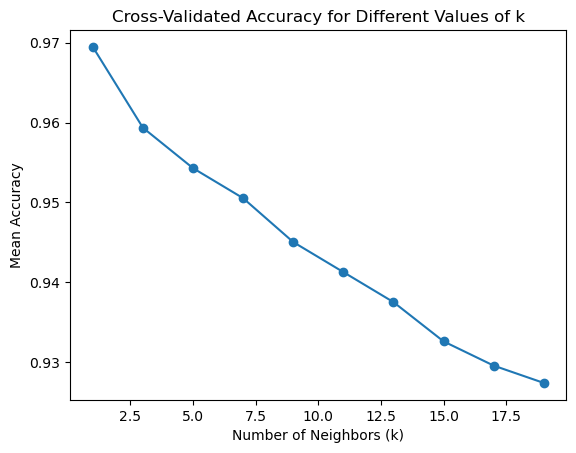

The best value of k is: 1


In [79]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

#your training data and labels loaded in X_train_balanced and y_train_balanced

# Create a range of odd k values to try
k_values = np.arange(1, 21, 2)

# List to store mean accuracy for each k
mean_accuracies = []

# Iterate over each k value
for k in k_values:
    # Create a k-NN classifier with the current k value
    knn_classifier_cv = KNeighborsClassifier(n_neighbors=k)
    
    # Perform 5-fold cross-validation and get mean accuracy
    accuracies = cross_val_score(knn_classifier_cv, X_train_balanced, y_train_balanced, cv=5, scoring='accuracy')
    mean_accuracy = np.mean(accuracies)
    
    # Append mean accuracy to the list
    mean_accuracies.append(mean_accuracy)

# Plot the mean accuracy for each k
plt.plot(k_values, mean_accuracies, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Accuracy')
plt.title('Cross-Validated Accuracy for Different Values of k')
plt.show()

# Find the best k value
best_k = k_values[np.argmax(mean_accuracies)]
print(f'The best value of k is: {best_k}')

In [80]:
#collect predictions on train data
y_hat = clf_knn.predict(X_train)

accuracy = accuracy_score(y_train, y_hat)
print("Best parameter Accuracy:",round(accuracy,2))

#collect predictions on validation data
y_hat = clf_knn.predict(X_val)

accuracy = accuracy_score(y_val, y_hat)
print("Best parameter Accuracy:",round(accuracy,2))

print('Training set score: {:.4f}'.format(clf_knn.score(X_train, y_train)))
print('Validation set score: {:.4f}'.format(clf_knn.score(X_val, y_val)))
print('Test set score: {:.4f}'.format(clf_knn.score(X_test, y_test)))

Best parameter Accuracy: 0.93
Best parameter Accuracy: 0.91
Training set score: 0.9290
Validation set score: 0.9118
Test set score: 0.9318


### For unbalanced data (X)

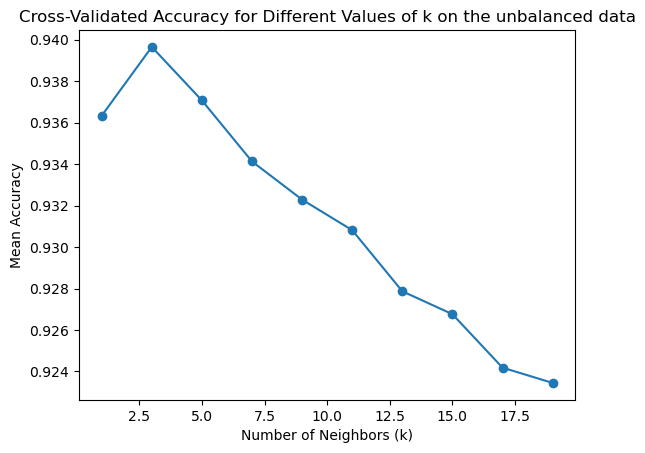

The best value of k for unbalanced dataset is: 3


In [81]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# your training data and labels loaded in X_train and y_train


# Create a range of odd k values to try
k_values = np.arange(1, 21, 2)

# List to store mean accuracy for each k
mean_accuracies = []

# Iterate over each k value
for k in k_values:
    # Create a k-NN classifier with the current k value
    knn_classifier_unbalance = KNeighborsClassifier(n_neighbors=k)
    
    # Perform 5-fold cross-validation and get mean accuracy
    accuracies = cross_val_score(knn_classifier_unbalance, X_train, y_train, cv=5, scoring='accuracy')
    mean_accuracy = np.mean(accuracies)
    
    # Append mean accuracy to the list
    mean_accuracies.append(mean_accuracy)

# Plot the mean accuracy for each k
plt.plot(k_values, mean_accuracies, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Accuracy')
plt.title('Cross-Validated Accuracy for Different Values of k on the unbalanced data')
plt.show()

# Find the best k value
best_k = k_values[np.argmax(mean_accuracies)]
print(f'The best value of k for unbalanced dataset is: {best_k}')

In [82]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

knn_classifier_unbalance = KNeighborsClassifier(n_neighbors=3)

# Train the classifier on the training data
knn_classifier_unbalance.fit(X_train_balanced, y_train_balanced)

# Make predictions on the test data
y_pred = knn_classifier_unbalance.predict(X_test)

# test set (X_test, y_test)
y_pred = knn_classifier_unbalance.predict(X_test)


# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

               precision    recall  f1-score   support

    high_risk       0.32      0.81      0.46        27
     low_risk       0.97      0.92      0.95       730
moderate_risk       0.86      0.83      0.84        93

     accuracy                           0.91       850
    macro avg       0.72      0.85      0.75       850
 weighted avg       0.94      0.91      0.92       850



### Validation Set

In [83]:
#collect predictions on train data
y_hat = knn_classifier_unbalance.predict(X_train)

accuracy = accuracy_score(y_train, y_hat)
print("Best parameter Accuracy:",round(accuracy,2))

#collect predictions on validation data
y_hat = knn_classifier_unbalance.predict(X_val)

accuracy = accuracy_score(y_val, y_hat)
print("Best parameter Accuracy:",round(accuracy,2))

Best parameter Accuracy: 0.96
Best parameter Accuracy: 0.9


### Check for overfitting and underfitting

In [84]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(knn_classifier_unbalance.score(X_train, y_train)))
print('Validation set score: {:.4f}'.format(knn_classifier_unbalance.score(X_val, y_val)))
print('Test set score: {:.4f}'.format(knn_classifier_unbalance.score(X_test, y_test)))

Training set score: 0.9610
Validation set score: 0.8956
Test set score: 0.9071


### SVC Using X

In [85]:
from sklearn.svm import SVC

svc = SVC()

# Train the classifier on the training data
svc.fit(X_train_balanced, y_train_balanced);

In [86]:
# Make predictions on the test set
y_pred = svc.predict(X_test)

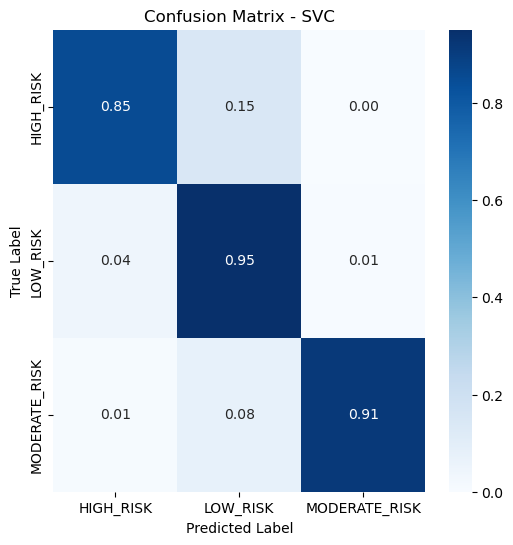

In [87]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names=['HIGH_RISK', 'LOW_RISK', 'MODERATE_RISK']

# Plot confusion matrix

y_pred = svc.predict(X_test)
cm = confusion_matrix(y_test, y_pred, normalize='true')
    
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix - SVC")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# test set (X_test, y_test)
y_pred = svc.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Evaluate precision
precision = precision_score(y_test, y_pred, average='weighted')

# Evaluate recall
recall = recall_score(y_test, y_pred, average='weighted')

# Print the results
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

Accuracy: 0.94
Precision: 0.96
Recall: 0.94


In [89]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

               precision    recall  f1-score   support

    high_risk       0.41      0.85      0.55        27
     low_risk       0.98      0.95      0.97       730
moderate_risk       0.96      0.91      0.93        93

     accuracy                           0.94       850
    macro avg       0.78      0.91      0.82       850
 weighted avg       0.96      0.94      0.95       850



In [90]:
# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Evaluate precision
precision = precision_score(y_test, y_pred, average='weighted')
print(f'Precision: {precision:.2f}')

# Evaluate recall
recall = recall_score(y_test, y_pred, average='weighted')
print(f'Recall: {recall:.2f}')


Accuracy: 0.94
Precision: 0.96
Recall: 0.94


In [91]:
#collect predictions on train data
y_hat = svc.predict(X_train)

accuracy = accuracy_score(y_train, y_hat)
print("Best parameter Accuracy:",round(accuracy,2))

#collect predictions on validation data
y_hat = svc.predict(X_val)

accuracy = accuracy_score(y_val, y_hat)
print("Best parameter Accuracy:",round(accuracy,2))

print('Training set score: {:.4f}'.format(svc.score(X_train, y_train)))
print('Validation set score: {:.4f}'.format(svc.score(X_val, y_val)))
print('Test set score: {:.4f}'.format(svc.score(X_test, y_test)))

Best parameter Accuracy: 0.95
Best parameter Accuracy: 0.94
Training set score: 0.9452
Validation set score: 0.9441
Test set score: 0.9435


## Decission Tree (X)

In [92]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, Normalizer, PowerTransformer, QuantileTransformer, StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
# Choose a classification algorithm (Decision Tree Classifier as an example)
model = DecisionTreeClassifier(random_state=3)

In [93]:
# Train the model using the training set
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=3)

In [94]:
# Make predictions on the testing set
y_pred = model.predict(X_test)

In [95]:
# Evaluate the model's performance using appropriate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted' )

# Display the evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9835
Precision: 0.9831
Recall: 0.9835
F1 Score: 0.9832


In [96]:
# Generate the classification report
report = classification_report(y_test, y_pred)

# Display the classification report
print("Classification Report:\n", report)

Classification Report:
                precision    recall  f1-score   support

    high_risk       0.88      0.78      0.82        27
     low_risk       0.99      0.99      0.99       730
moderate_risk       0.99      0.96      0.97        93

     accuracy                           0.98       850
    macro avg       0.95      0.91      0.93       850
 weighted avg       0.98      0.98      0.98       850



### ROC Curve

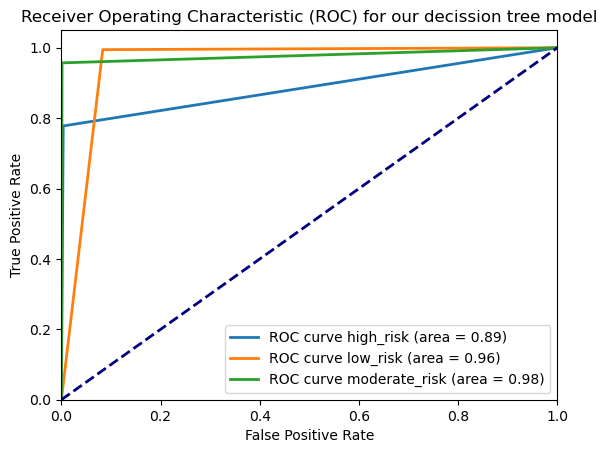

In [97]:
# Learn to predict each class against the other
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

label_binarizer = LabelBinarizer().fit(y_train)

y_onehot_test = label_binarizer.transform(y_test)

y_onehot_test.shape  # (n_samples, n_classes)


model.score(X_train, y_train)

y_score = model.predict_proba(X_test)

y_pred = model.predict(X_test)


# Compute ROC curve and ROC area for each class

classes = np.unique(y)
n_classes = len(np.unique(y))


fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_onehot_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_onehot_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
lw = 2


#plot each roc curve in the onevsrest classifier.
#class setosa vs rest, class versicolor vs rest and class virginica vs rest
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
            lw=lw, label='ROC curve %s (area = %0.2f)' % (classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for our decission tree model')
plt.legend(loc="lower right")
plt.show()

C:\Users\mse98\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


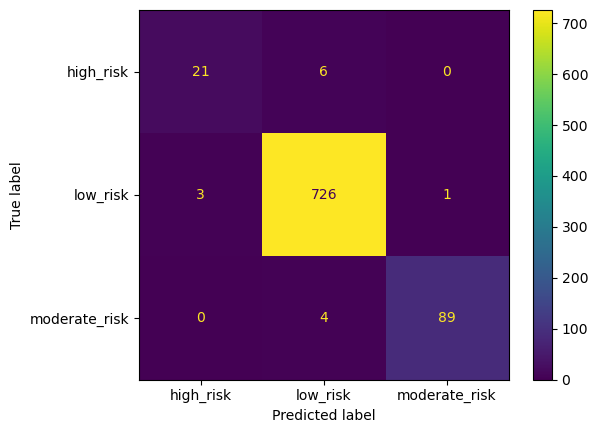

In [98]:
plot_confusion_matrix(model, X_test, y_test)

In [99]:
#collect predictions on train data
y_hat = model.predict(X_train)

accuracy = accuracy_score(y_train, y_hat)
print("Best parameter Accuracy:",round(accuracy,2))

#collect predictions on validation data
y_hat = model.predict(X_val)

accuracy = accuracy_score(y_val, y_hat)
print("Best parameter Accuracy:",round(accuracy,2))

print('Training set score: {:.4f}'.format(model.score(X_train, y_train)))
print('Validation set score: {:.4f}'.format(model.score(X_val, y_val)))
print('Test set score: {:.4f}'.format(model.score(X_test, y_test)))

Best parameter Accuracy: 1.0
Best parameter Accuracy: 0.98
Training set score: 1.0000
Validation set score: 0.9779
Test set score: 0.9835


## Confusion matrix for all classifiers (X)


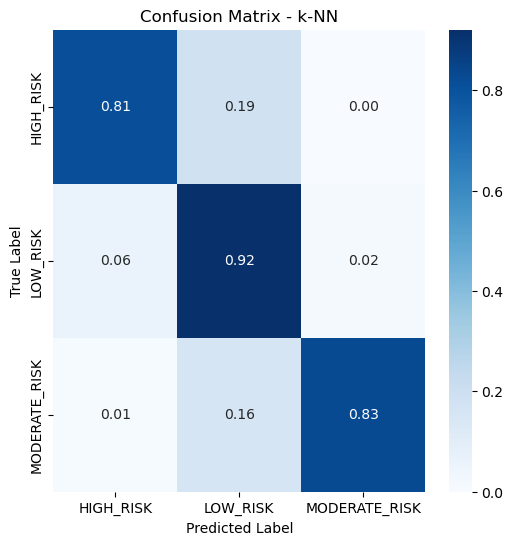

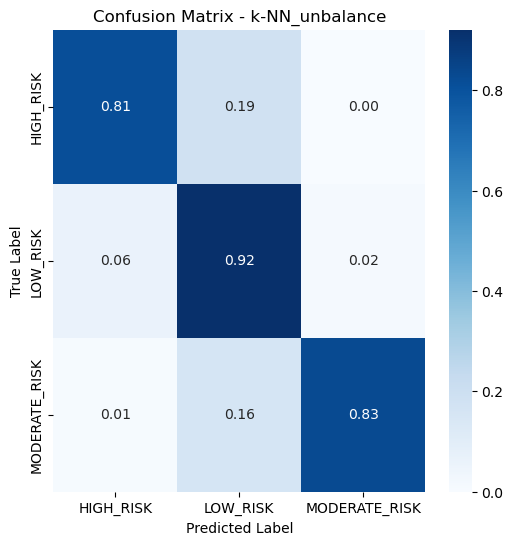

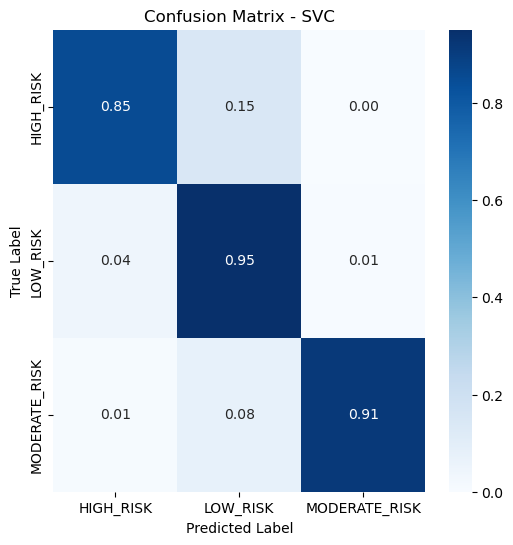

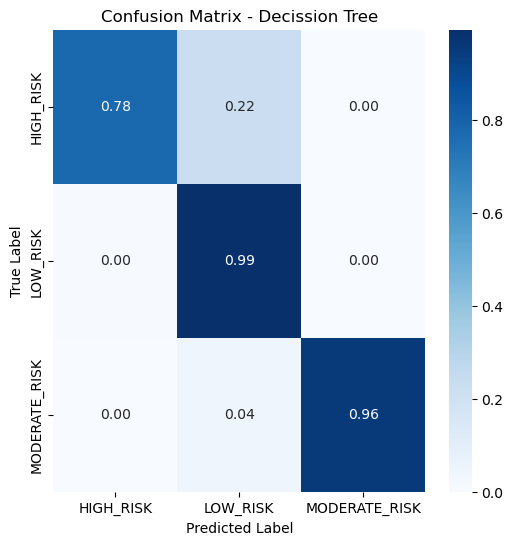

In [100]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names=['HIGH_RISK', 'LOW_RISK', 'MODERATE_RISK']


classifiers = [knn_classifier,knn_classifier_unbalance, svc, model]
classifier_names = ['k-NN', 'k-NN_unbalance','SVC', 'Decission Tree' ]

# Plot confusion matrix for each classifier
for clf, name in zip(classifiers, classifier_names):
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, normalize='true')

    
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


### For balanced data (X3)

In [101]:
from sklearn.neighbors import KNeighborsClassifier

knn_classifier3 = KNeighborsClassifier(n_neighbors=3)

# Train the classifier on the training data
knn_classifier3.fit(X3_train_balanced, y3_train_balanced)

KNeighborsClassifier(n_neighbors=3)

In [102]:
# Make predictions on the test data
y3_pred = knn_classifier3.predict(X3_test)

### Grid Search Cross Validation

In [103]:
from sklearn.model_selection import GridSearchCV

#make a dictionary, where the parameter we want to set, and the range of values we want to cross-validate over
#in this example I am going to set the k parameter in kNN, where I am testing between 1 to 7.
parameters = {
    "n_neighbors" : [1,3,5,7]
}

clf3 = GridSearchCV(knn_classifier3,param_grid=parameters)
clf3.fit(X3_train, y3_train)

#here we can see the best parameter was for n_neighbors
print('Best parameter for n_neighbors', clf3.best_params_)

#collect predictions on test data
y3_hat = clf3.predict(X3_test)


#calculate the score - accuracy / error or other metrics.
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y3_test, y3_hat)
print('accuracy', accuracy)

Best parameter for n_neighbors {'n_neighbors': 3}
accuracy 0.9423529411764706


### Validation Set

In [104]:
accuracies = []
# Test for number of neighbours 1 to 20
for  i in range(1,20):
    #build classifier with our current parameter.
    clf_knn3 = KNeighborsClassifier(n_neighbors=i,weights='uniform')
          
    #fit our parameterised model to the cross-validated data.
    clf_knn3.fit(X3_train, y3_train)
        
    #obtain predictions on the cv test set.
    y3_hat_cv = clf_knn3.predict(X3_val)


    #append the accuracies to the list of all of them.
    accuracies.append(accuracy_score(y3_val, y3_hat_cv))
    print('Neighbours:',i, '\ Accuracy:',round(accuracies[i-1],2))
    
#print(accuracies)

# pick the best parameter as the index of the argmax in the accuracies (-1 to account for indexing starting at 0)
#argmax returns the indices of the maximum values along an axis. 
best_paramater = np.argmax(accuracies)+1
print('Best parameter is:',best_paramater)

Neighbours: 1 \ Accuracy: 0.94
Neighbours: 2 \ Accuracy: 0.91
Neighbours: 3 \ Accuracy: 0.94
Neighbours: 4 \ Accuracy: 0.93
Neighbours: 5 \ Accuracy: 0.93
Neighbours: 6 \ Accuracy: 0.93
Neighbours: 7 \ Accuracy: 0.93
Neighbours: 8 \ Accuracy: 0.92
Neighbours: 9 \ Accuracy: 0.93
Neighbours: 10 \ Accuracy: 0.92
Neighbours: 11 \ Accuracy: 0.92
Neighbours: 12 \ Accuracy: 0.92
Neighbours: 13 \ Accuracy: 0.92
Neighbours: 14 \ Accuracy: 0.91
Neighbours: 15 \ Accuracy: 0.91
Neighbours: 16 \ Accuracy: 0.91
Neighbours: 17 \ Accuracy: 0.91
Neighbours: 18 \ Accuracy: 0.91
Neighbours: 19 \ Accuracy: 0.91
Best parameter is: 1


In [105]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# test set (X3_test, y3_test)
y3_pred = knn_classifier3.predict(X3_test)

# Evaluate accuracy
accuracy = accuracy_score(y3_test, y3_pred)

# Evaluate precision
precision = precision_score(y3_test, y3_pred, average='weighted')

# Evaluate recall
recall = recall_score(y3_test, y3_pred, average='weighted')

# Print the results
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

Accuracy: 0.91
Precision: 0.94
Recall: 0.91


In [106]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y3_test,y3_pred))

               precision    recall  f1-score   support

    high_risk       0.33      0.81      0.47        27
     low_risk       0.97      0.92      0.95       730
moderate_risk       0.87      0.84      0.85        93

     accuracy                           0.91       850
    macro avg       0.72      0.86      0.76       850
 weighted avg       0.94      0.91      0.92       850



### Check for fitting and underfitting

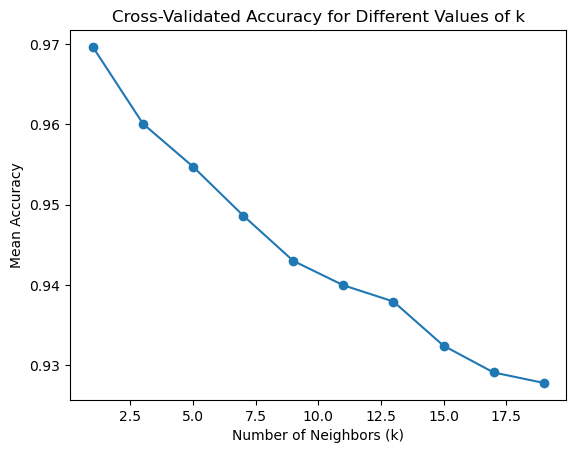

The best value of k is: 1


In [107]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

#your training data and labels loaded in X3_train_balanced and y3_train_balanced

# Create a range of odd k values to try
k_values = np.arange(1, 21, 2)

# List to store mean accuracy for each k
mean_accuracies = []

# Iterate over each k value
for k in k_values:
    # Create a k-NN classifier with the current k value
    knn_classifier_cv = KNeighborsClassifier(n_neighbors=k)
    
    # Perform 5-fold cross-validation and get mean accuracy
    accuracies = cross_val_score(knn_classifier_cv, X3_train_balanced, y3_train_balanced, cv=5, scoring='accuracy')
    mean_accuracy = np.mean(accuracies)
    
    # Append mean accuracy to the list
    mean_accuracies.append(mean_accuracy)

# Plot the mean accuracy for each k
plt.plot(k_values, mean_accuracies, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Accuracy')
plt.title('Cross-Validated Accuracy for Different Values of k')
plt.show()

# Find the best k value
best_k = k_values[np.argmax(mean_accuracies)]
print(f'The best value of k is: {best_k}')

In [108]:
#collect predictions on train data
y3_hat = clf_knn3.predict(X3_train)

accuracy = accuracy_score(y3_train, y3_hat)
print("Best parameter Accuracy:",round(accuracy,2))

#collect predictions on validation data
y3_hat = clf_knn3.predict(X3_val)

accuracy = accuracy_score(y3_val, y3_hat)
print("Best parameter Accuracy:",round(accuracy,2))

print('Training set score: {:.4f}'.format(clf_knn3.score(X3_train, y3_train)))
print('Validation set score: {:.4f}'.format(clf_knn3.score(X3_val, y3_val)))
print('Test set score: {:.4f}'.format(clf_knn3.score(X3_test, y3_test)))

Best parameter Accuracy: 0.93
Best parameter Accuracy: 0.91
Training set score: 0.9290
Validation set score: 0.9118
Test set score: 0.9318


## For unbalanced data (X3)

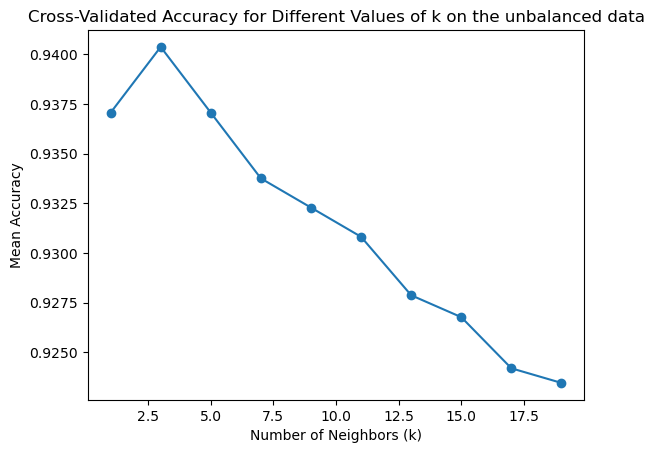

The best value of k for unbalanced dataset is: 3


In [109]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# your training data and labels loaded in X3_train and y3_train


# Create a range of odd k values to try
k_values = np.arange(1, 21, 2)

# List to store mean accuracy for each k
mean_accuracies = []

# Iterate over each k value
for k in k_values:
    # Create a k-NN classifier with the current k value
    knn_classifier_unbalance3 = KNeighborsClassifier(n_neighbors=k)
    
    # Perform 5-fold cross-validation and get mean accuracy
    accuracies = cross_val_score(knn_classifier_unbalance3, X3_train, y3_train, cv=5, scoring='accuracy')
    mean_accuracy = np.mean(accuracies)
    
    # Append mean accuracy to the list
    mean_accuracies.append(mean_accuracy)

# Plot the mean accuracy for each k
plt.plot(k_values, mean_accuracies, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Accuracy')
plt.title('Cross-Validated Accuracy for Different Values of k on the unbalanced data')
plt.show()

# Find the best k value
best_k = k_values[np.argmax(mean_accuracies)]
print(f'The best value of k for unbalanced dataset is: {best_k}')

In [110]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

knn_classifier_unbalance3 = KNeighborsClassifier(n_neighbors=3)

# Train the classifier on the training data
knn_classifier_unbalance3.fit(X3_train_balanced, y3_train_balanced)

# Make predictions on the test data
y3_pred = knn_classifier_unbalance3.predict(X3_test)

# test set (X3_test, y3_test)
y3_pred = knn_classifier_unbalance3.predict(X3_test)


# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y3_test,y3_pred))

               precision    recall  f1-score   support

    high_risk       0.33      0.81      0.47        27
     low_risk       0.97      0.92      0.95       730
moderate_risk       0.87      0.84      0.85        93

     accuracy                           0.91       850
    macro avg       0.72      0.86      0.76       850
 weighted avg       0.94      0.91      0.92       850



### Check for overfitting and underfitting

In [111]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(knn_classifier_unbalance3.score(X3_train, y3_train)))
print('Validation set score: {:.4f}'.format(knn_classifier_unbalance3.score(X3_val, y3_val)))
print('Test set score: {:.4f}'.format(knn_classifier_unbalance3.score(X3_test, y3_test)))

Training set score: 0.9650
Validation set score: 0.9029
Test set score: 0.9094


### SVC Using X3

In [112]:
from sklearn.svm import SVC

svc3 = SVC()

# Train the classifier on the training data
svc3.fit(X3_train_balanced, y3_train_balanced);

In [113]:
# Make predictions on the test set
y3_pred = svc3.predict(X3_test)

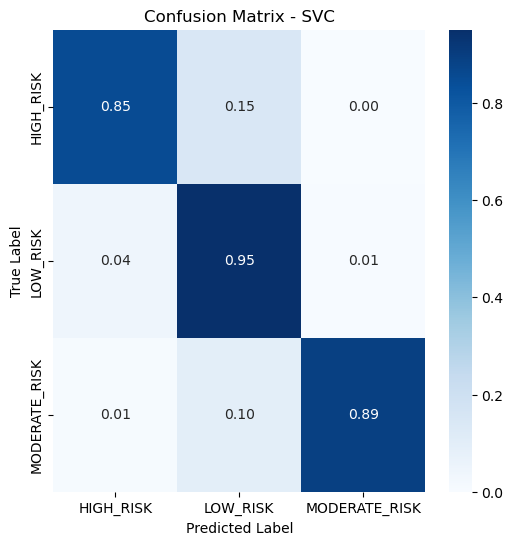

In [114]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names=['HIGH_RISK', 'LOW_RISK', 'MODERATE_RISK']

# Plot confusion matrix

y3_pred = svc3.predict(X3_test)
cm = confusion_matrix(y3_test, y3_pred, normalize='true')
    
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix - SVC")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [115]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# test set (X3_test, y3_test)
y3_pred = svc3.predict(X3_test)

# Evaluate accuracy
accuracy = accuracy_score(y3_test, y3_pred)

# Evaluate precision
precision = precision_score(y3_test, y3_pred, average='weighted')

# Evaluate recall
recall = recall_score(y3_test, y3_pred, average='weighted')

# Print the results
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

Accuracy: 0.94
Precision: 0.96
Recall: 0.94


In [116]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y3_test,y3_pred))

               precision    recall  f1-score   support

    high_risk       0.42      0.85      0.56        27
     low_risk       0.98      0.95      0.97       730
moderate_risk       0.94      0.89      0.92        93

     accuracy                           0.94       850
    macro avg       0.78      0.90      0.81       850
 weighted avg       0.96      0.94      0.95       850



In [117]:
# Evaluate accuracy
accuracy = accuracy_score(y3_test, y3_pred)
print(f'Accuracy: {accuracy:.2f}')

# Evaluate precision
precision = precision_score(y3_test, y3_pred, average='weighted')
print(f'Precision: {precision:.2f}')

# Evaluate recall
recall = recall_score(y3_test, y3_pred, average='weighted')
print(f'Recall: {recall:.2f}')

Accuracy: 0.94
Precision: 0.96
Recall: 0.94


In [118]:
#collect predictions on train data
y3_hat = svc3.predict(X3_train)

accuracy = accuracy_score(y3_train, y3_hat)
print("Best parameter Accuracy:",round(accuracy,2))

#collect predictions on validation data
y3_hat = svc3.predict(X3_val)

accuracy = accuracy_score(y3_val, y3_hat)
print("Best parameter Accuracy:",round(accuracy,2))

print('Training set score: {:.4f}'.format(svc3.score(X3_train, y3_train)))
print('Validation set score: {:.4f}'.format(svc3.score(X3_val, y3_val)))
print('Test set score: {:.4f}'.format(svc3.score(X3_test, y3_test)))

Best parameter Accuracy: 0.95
Best parameter Accuracy: 0.94
Training set score: 0.9459
Validation set score: 0.9397
Test set score: 0.9412


## Decison Tree (X3)

In [119]:
# Choose a classification algorithm (Decision Tree Classifier as an example)
model3 = DecisionTreeClassifier(random_state=3)

In [120]:
# Train the model using the training set
model3.fit(X3_train, y3_train)

DecisionTreeClassifier(random_state=3)

In [121]:
# Make predictions on the testing set
y3_pred = model3.predict(X3_test)


In [122]:
# Evaluate the model's performance using appropriate metrics
accuracy = accuracy_score(y3_test, y3_pred)
precision = precision_score(y3_test, y3_pred, average='weighted')
recall = recall_score(y3_test, y3_pred, average='weighted')
f1 = f1_score(y3_test, y3_pred, average='weighted' )

# Display the evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9800
Precision: 0.9794
Recall: 0.9800
F1 Score: 0.9796


In [123]:
# Generate the classification report
report = classification_report(y3_test, y3_pred)

# Display the classification report
print("Classification Report:\n", report)

Classification Report:
                precision    recall  f1-score   support

    high_risk       0.83      0.74      0.78        27
     low_risk       0.99      0.99      0.99       730
moderate_risk       0.98      0.96      0.97        93

     accuracy                           0.98       850
    macro avg       0.93      0.90      0.91       850
 weighted avg       0.98      0.98      0.98       850



### ROC Curve

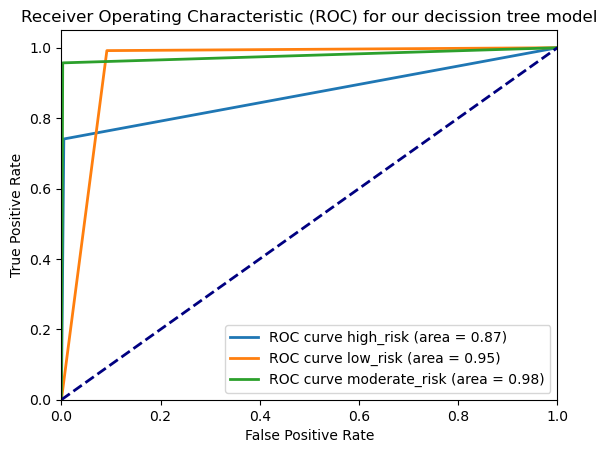

In [124]:
# Learn to predict each class against the other
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

label_binarizer = LabelBinarizer().fit(y_train)

y_onehot_test = label_binarizer.transform(y_test)

y_onehot_test.shape  # (n_samples, n_classes)


model3.score(X3_train, y3_train)

y_score = model3.predict_proba(X3_test)

y_pred = model3.predict(X3_test)


# Compute ROC curve and ROC area for each class

classes = np.unique(y)
n_classes = len(np.unique(y))


fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_onehot_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_onehot_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
lw = 2


#plot each roc curve in the onevsrest classifier.
#class setosa vs rest, class versicolor vs rest and class virginica vs rest
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
            lw=lw, label='ROC curve %s (area = %0.2f)' % (classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for our decission tree model')
plt.legend(loc="lower right")
plt.show()

C:\Users\mse98\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


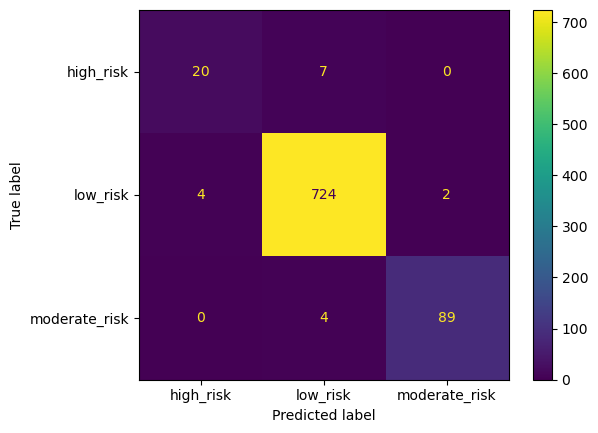

In [125]:
plot_confusion_matrix(model3, X3_test, y3_test)

In [126]:
#collect predictions on train data
y3_hat = model3.predict(X3_train)

accuracy = accuracy_score(y3_train, y3_hat)
print("Best parameter Accuracy:",round(accuracy,2))

#collect predictions on validation data
y3_hat = model3.predict(X3_val)

accuracy = accuracy_score(y3_val, y3_hat)
print("Best parameter Accuracy:",round(accuracy,2))

print('Training set score: {:.4f}'.format(model3.score(X3_train, y3_train)))
print('Validation set score: {:.4f}'.format(model3.score(X3_val, y3_val)))
print('Test set score: {:.4f}'.format(model3.score(X3_test, y3_test)))

Best parameter Accuracy: 1.0
Best parameter Accuracy: 0.98
Training set score: 1.0000
Validation set score: 0.9779
Test set score: 0.9800


## Confusion matrix for all classifiers (X3)

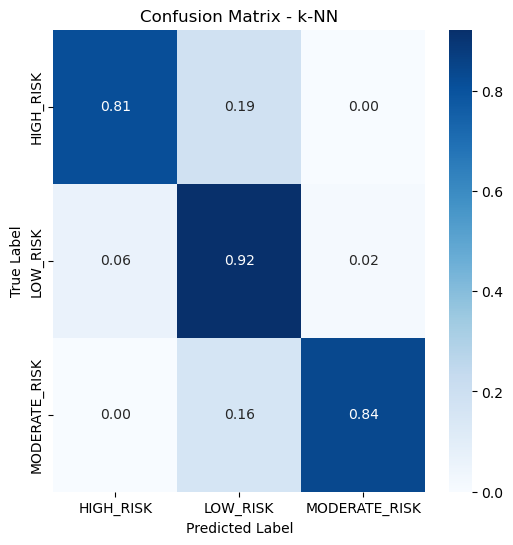

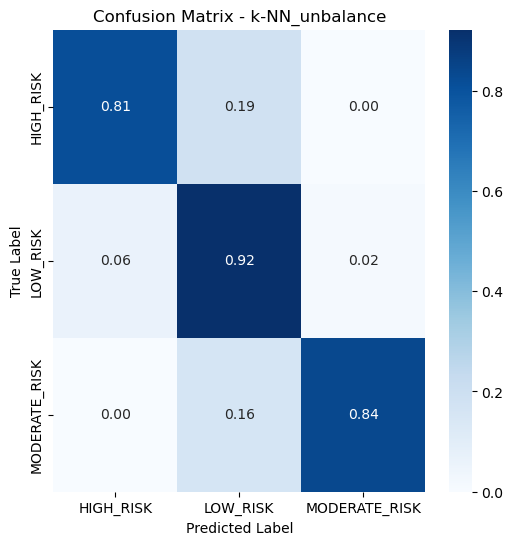

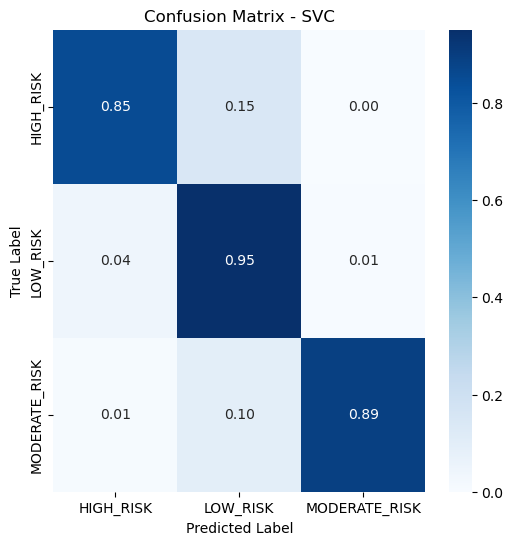

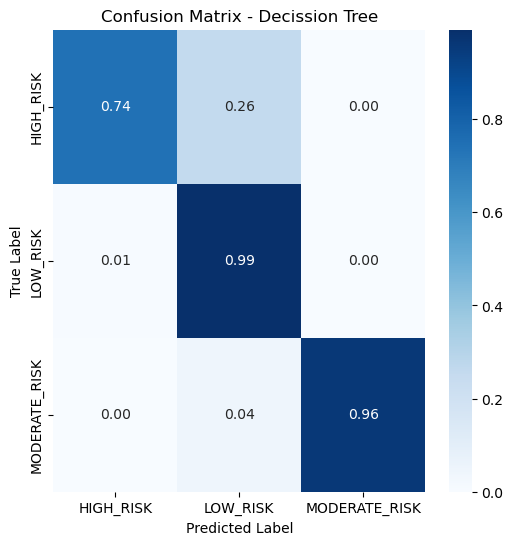

In [127]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names=['HIGH_RISK', 'LOW_RISK', 'MODERATE_RISK']


classifiers = [knn_classifier3,knn_classifier_unbalance3, svc3, model3]
classifier_names = ['k-NN', 'k-NN_unbalance','SVC', 'Decission Tree' ]

# Plot confusion matrix for each classifier
for clf, name in zip(classifiers, classifier_names):
    y3_pred = clf.predict(X3_test)
    cm = confusion_matrix(y3_test, y3_pred, normalize='true')
    
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

## Predicting the target

In [128]:
predictedTarget

,id,predicted_target
0,PA6001,NaN
1,PA6002,NaN
2,PA6003,NaN
3,PA6004,NaN
4,PA6005,NaN
...,...,...
745,PA6746,NaN
746,PA6747,NaN
747,PA6748,NaN
748,PA6749,NaN


In [129]:
disease_test

,id,age,gender,sick,pregnant,test_X1,test_X2,test_X3,test_X4,test_X5,...,enlargement,tumor,disorder,medication_A,medication_B,mental_health,mood_stabiliser,surgery,treatment_type1,suspect
0,PA6001,22,female,no,no,0.500,1.7,83.0,0.86,97.0,...,no,no,no,no,no,no,no,no,no,no
1,PA6002,42,male,no,no,0.060,2.0,79.0,0.81,98.0,...,no,no,no,no,no,no,no,no,no,no
2,PA6003,42,male,no,no,0.045,2.1,111.0,0.89,125.0,...,no,no,no,no,no,no,no,no,no,no
3,PA6004,42,female,no,no,1.900,2.0,114.0,1.33,86.0,...,no,no,no,no,no,no,no,no,no,no
4,PA6005,55,male,no,no,0.570,1.4,75.0,0.72,104.0,...,no,no,no,no,no,yes,no,no,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,PA6746,55,male,no,no,1.300,NaN,72.0,0.75,96.0,...,no,no,no,no,no,no,no,no,no,no
746,PA6747,62,female,no,no,1.400,NaN,104.0,1.12,93.0,...,no,no,no,no,no,no,no,no,no,no
747,PA6748,54,female,no,no,1.900,2.0,88.0,0.95,92.0,...,no,no,no,no,no,no,no,no,no,no
748,PA6749,69,female,no,no,0.010,2.4,127.0,0.84,152.0,...,no,no,no,no,no,no,no,no,no,no


In [130]:
disease_test = disease_test.drop(disease_test[disease_test['age'] > 100].index)
disease_test = disease_test.drop(disease_test[(disease_test['age'] > 45) & (disease_test['pregnant'] == 'yes')].index)
disease_test = disease_test.drop('test_X6', axis=1)
disease_test = disease_test.drop('disorder', axis=1)
disease_test.T

,0,1,2,3,4,5,6,7,8,9,...,740,741,742,743,744,745,746,747,748,749
id,PA6001,PA6002,PA6003,PA6004,PA6005,PA6006,PA6007,PA6008,PA6009,PA6010,...,PA6741,PA6742,PA6743,PA6744,PA6745,PA6746,PA6747,PA6748,PA6749,PA6750
age,22,42,42,42,55,41,72,67,56,73,...,27,62,30,38,76,55,62,54,69,51
gender,female,male,male,female,male,female,male,female,female,female,...,female,female,female,female,female,male,female,female,female,female
sick,no,no,no,no,no,no,no,no,no,no,...,no,no,no,no,no,no,no,no,no,no
pregnant,no,no,no,no,no,no,no,no,no,no,...,no,no,no,no,no,no,no,no,no,no
test_X1,0.5,0.06,0.045,1.9,0.57,0.1,1.1,3.1,44.0,1.9,...,0.05,3.9,0.4,0.045,27.0,1.3,1.4,1.9,0.01,4.0
test_X2,1.7,2.0,2.1,2.0,1.4,2.1,1.9,1.5,1.6,2.8,...,2.8,NaN,1.9,1.6,2.3,NaN,NaN,2.0,2.4,1.7
test_X3,83.0,79.0,111.0,114.0,75.0,148.0,119.0,108.0,28.0,104.0,...,131.0,84.0,142.0,149.0,135.0,72.0,104.0,88.0,127.0,70.0
test_X4,0.86,0.81,0.89,1.33,0.72,1.44,0.96,0.94,0.97,1.23,...,1.26,1.02,1.02,0.97,1.54,0.75,1.12,0.95,0.84,0.9
test_X5,97.0,98.0,125.0,86.0,104.0,103.0,124.0,115.0,29.0,85.0,...,104.0,82.0,139.0,154.0,88.0,96.0,93.0,92.0,152.0,78.0


## Missing values

In [131]:
disease_test.isna().sum()

id                   0
age                  0
gender              26
sick                 0
pregnant             0
test_X1             76
test_X2            208
test_X3             33
test_X4             72
test_X5             71
concern_type1        0
concern_type2        0
enlargement          0
tumor                0
medication_A         0
medication_B         0
mental_health        0
mood_stabiliser      0
surgery              0
treatment_type1      0
suspect              0
dtype: int64

In [132]:
disease_test.gender.describe()

count        724
unique         2
top       female
freq         507
Name: gender, dtype: object

In [133]:
disease_test.describe()

,age,test_X1,test_X2,test_X3,test_X4,test_X5
count,750.000000,674.000000,542.000000,717.000000,678.000000,679.000000
mean,52.956000,6.674659,2.001181,104.772664,0.963451,111.738586
std,18.639921,25.900959,0.768551,35.425431,0.171272,48.448464
min,1.000000,0.005000,0.200000,2.900000,0.190000,2.400000
25%,38.000000,0.442500,1.600000,86.000000,0.870000,94.000000
50%,56.000000,1.400000,1.900000,103.000000,0.960000,109.000000
75%,68.000000,3.100000,2.300000,120.000000,1.050000,125.000000
max,92.000000,393.000000,8.500000,273.000000,2.120000,839.000000


In [134]:
disease_test.test_X1 = disease_test.test_X1.fillna(disease_test.test_X1.median())

In [135]:
disease_test.test_X2 = disease_test.test_X2.fillna(disease_test.test_X2.median())

In [136]:
disease_test.test_X3 = disease_test.test_X3.fillna(disease_test.test_X3.median())

In [137]:
disease_test.test_X4 = disease_test.test_X4.fillna(disease_test.test_X4.mean())

In [138]:
disease_test.test_X5 = disease_test.test_X5.fillna(disease_test.test_X5.median())

In [139]:
disease_test.gender = disease_test.gender.fillna('female')

In [140]:
disease_test.isna().sum().any()

False

## Encoding

In [141]:
disease_test = disease_test.replace("no", 0.0)


In [142]:
disease_test = disease_test.replace("yes", 1.0)


In [143]:
disease_test = disease_test.replace("male", 0.0)


In [144]:
disease_test = disease_test.replace("female", 1.0)
disease_test

,id,age,gender,sick,pregnant,test_X1,test_X2,test_X3,test_X4,test_X5,...,concern_type2,enlargement,tumor,medication_A,medication_B,mental_health,mood_stabiliser,surgery,treatment_type1,suspect
0,PA6001,22,1.0,0.0,0.0,0.500,1.7,83.0,0.86,97.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,PA6002,42,0.0,0.0,0.0,0.060,2.0,79.0,0.81,98.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,PA6003,42,0.0,0.0,0.0,0.045,2.1,111.0,0.89,125.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,PA6004,42,1.0,0.0,0.0,1.900,2.0,114.0,1.33,86.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,PA6005,55,0.0,0.0,0.0,0.570,1.4,75.0,0.72,104.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,PA6746,55,0.0,0.0,0.0,1.300,1.9,72.0,0.75,96.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
746,PA6747,62,1.0,0.0,0.0,1.400,1.9,104.0,1.12,93.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
747,PA6748,54,1.0,0.0,0.0,1.900,2.0,88.0,0.95,92.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
748,PA6749,69,1.0,0.0,0.0,0.010,2.4,127.0,0.84,152.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [145]:
X_target = disease_test[['age', 'gender', 'sick', 'pregnant','test_X1', 'test_X2', 
         'test_X3','test_X4', 'test_X5', 'concern_type1',
               'concern_type2', 'enlargement', 'tumor',
               'medication_A', 'medication_B', 'mental_health',
               'mood_stabiliser', 'surgery', 'treatment_type1', 'suspect']]

In [146]:
predicted_target = svc.predict(X_target)
predicted_target

array(['low_risk', 'low_risk', 'low_risk', 'low_risk', 'low_risk',
       'low_risk', 'low_risk', 'low_risk', 'moderate_risk', 'low_risk',
       'low_risk', 'low_risk', 'low_risk', 'low_risk', 'low_risk',
       'moderate_risk', 'low_risk', 'low_risk', 'low_risk', 'low_risk',
       'low_risk', 'low_risk', 'moderate_risk', 'low_risk', 'low_risk',
       'moderate_risk', 'moderate_risk', 'low_risk', 'low_risk',
       'low_risk', 'low_risk', 'high_risk', 'low_risk', 'low_risk',
       'low_risk', 'low_risk', 'low_risk', 'low_risk', 'low_risk',
       'low_risk', 'low_risk', 'low_risk', 'low_risk', 'low_risk',
       'low_risk', 'low_risk', 'low_risk', 'low_risk', 'low_risk',
       'low_risk', 'low_risk', 'low_risk', 'low_risk', 'low_risk',
       'high_risk', 'low_risk', 'low_risk', 'low_risk', 'low_risk',
       'low_risk', 'low_risk', 'low_risk', 'low_risk', 'low_risk',
       'low_risk', 'low_risk', 'low_risk', 'moderate_risk', 'low_risk',
       'low_risk', 'low_risk', 'low_risk',

In [147]:
predicted_target2 = pd.DataFrame(predicted_target)

In [148]:
predicted_target2=predicted_target2.rename(columns={0: "predicted_target"})

In [149]:
#df['C'] = np.arange(len(df))
disease_test['number'] = np.arange(len(disease_test))
disease_test

,id,age,gender,sick,pregnant,test_X1,test_X2,test_X3,test_X4,test_X5,...,enlargement,tumor,medication_A,medication_B,mental_health,mood_stabiliser,surgery,treatment_type1,suspect,number
0,PA6001,22,1.0,0.0,0.0,0.500,1.7,83.0,0.86,97.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,PA6002,42,0.0,0.0,0.0,0.060,2.0,79.0,0.81,98.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,PA6003,42,0.0,0.0,0.0,0.045,2.1,111.0,0.89,125.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,PA6004,42,1.0,0.0,0.0,1.900,2.0,114.0,1.33,86.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,PA6005,55,0.0,0.0,0.0,0.570,1.4,75.0,0.72,104.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,PA6746,55,0.0,0.0,0.0,1.300,1.9,72.0,0.75,96.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,745
746,PA6747,62,1.0,0.0,0.0,1.400,1.9,104.0,1.12,93.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,746
747,PA6748,54,1.0,0.0,0.0,1.900,2.0,88.0,0.95,92.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,747
748,PA6749,69,1.0,0.0,0.0,0.010,2.4,127.0,0.84,152.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,748


In [150]:
predicted_target2['number'] = np.arange(len(predicted_target2))

predicted_target2

,predicted_target,number
0,low_risk,0
1,low_risk,1
2,low_risk,2
3,low_risk,3
4,low_risk,4
...,...,...
745,low_risk,745
746,low_risk,746
747,low_risk,747
748,low_risk,748


In [151]:
predicted_target3 = disease_test.merge(predicted_target2)

predicted_target3.drop(['age', 'gender', 'sick', 'pregnant','test_X1', 'test_X2', 
         'test_X3','test_X4', 'test_X5',  'concern_type1',
               'concern_type2', 'enlargement', 'tumor',
               'medication_A', 'medication_B', 'mental_health',
               'mood_stabiliser', 'surgery', 'treatment_type1', 'suspect', 'number'], axis=1, inplace=True)

predicted_target3

,id,predicted_target
0,PA6001,low_risk
1,PA6002,low_risk
2,PA6003,low_risk
3,PA6004,low_risk
4,PA6005,low_risk
...,...,...
745,PA6746,low_risk
746,PA6747,low_risk
747,PA6748,low_risk
748,PA6749,low_risk


In [152]:
predicted_target3.to_csv(r'C:\Users\mse98\Desktop\predicted_target.csv', index = False)

## 4. Unsupervised Learning Using Clustering Algorithms:
- Finally we exclude the medical diagnosis (target) field during clustering to ensure
unsupervised learning.
- Unsupervised clustering algorithms (e.g. k-Means, hierarchical clustering, …)
were applied to the pre-processed dataset based on your judgment of the task.
- We use Scatter plots on the clusters to visually represent the data.
- We analyse the formed clusters, observing distinct patterns or groups related to
different categories of health status (Low risk, Moderate risk, High risk).
 

In [153]:
disease_train2.head()

,id,age,gender,sick,pregnant,test_X1,test_X2,test_X3,test_X4,test_X5,...,enlargement,tumor,medication_A,medication_B,mental_health,mood_stabiliser,surgery,treatment_type1,suspect,target
0,PA1001,59,0.0,0.0,0.0,7.8,1.9,89.0,0.850000,105.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,moderate_risk
1,PA1002,48,1.0,0.0,0.0,1.5,2.5,101.0,0.970000,104.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,low_risk
2,PA1003,77,0.0,0.0,0.0,7.3,1.2,57.0,1.280000,44.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,moderate_risk
3,PA1004,42,1.0,0.0,0.0,1.2,2.5,106.0,0.980000,108.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low_risk
4,PA1005,38,1.0,0.0,0.0,0.6,1.9,95.0,0.970808,107.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low_risk


In [154]:
disease_train2.isnull().sum()

id                 0
age                0
gender             0
sick               0
pregnant           0
test_X1            0
test_X2            0
test_X3            0
test_X4            0
test_X5            0
concern_type1      0
concern_type2      0
enlargement        0
tumor              0
medication_A       0
medication_B       0
mental_health      0
mood_stabiliser    0
surgery            0
treatment_type1    0
suspect            0
target             0
dtype: int64

In [155]:
cols = ['age', 'gender', 'sick', 'pregnant','test_X1', 'test_X2', 
         'test_X3','test_X4', 'test_X5',  'concern_type1',
               'concern_type2', 'enlargement', 'tumor',
               'medication_A', 'medication_B', 'mental_health',
               'mood_stabiliser', 'surgery', 'treatment_type1', 'suspect']

In [156]:
disease_train4 = disease_train2[['age', 'gender', 'sick', 'pregnant','test_X1', 'test_X2', 
         'test_X3','test_X4', 'test_X5',  'concern_type1',
               'concern_type2', 'enlargement', 'tumor',
               'medication_A', 'medication_B', 'mental_health',
               'mood_stabiliser', 'surgery', 'treatment_type1', 'suspect']]
disease_train4

,age,gender,sick,pregnant,test_X1,test_X2,test_X3,test_X4,test_X5,concern_type1,concern_type2,enlargement,tumor,medication_A,medication_B,mental_health,mood_stabiliser,surgery,treatment_type1,suspect
0,59,0.0,0.0,0.0,7.8,1.9,89.0,0.850000,105.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,48,1.0,0.0,0.0,1.5,2.5,101.0,0.970000,104.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,77,0.0,0.0,0.0,7.3,1.2,57.0,1.280000,44.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,42,1.0,0.0,0.0,1.2,2.5,106.0,0.980000,108.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,38,1.0,0.0,0.0,0.6,1.9,95.0,0.970808,107.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4245,29,0.0,0.0,0.0,0.5,2.3,105.0,0.860000,122.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4246,46,1.0,0.0,0.0,35.0,1.2,16.0,0.860000,19.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4247,72,1.0,0.0,0.0,3.4,2.1,88.0,0.960000,92.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4248,94,1.0,0.0,0.0,3.9,1.9,157.0,1.020000,154.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


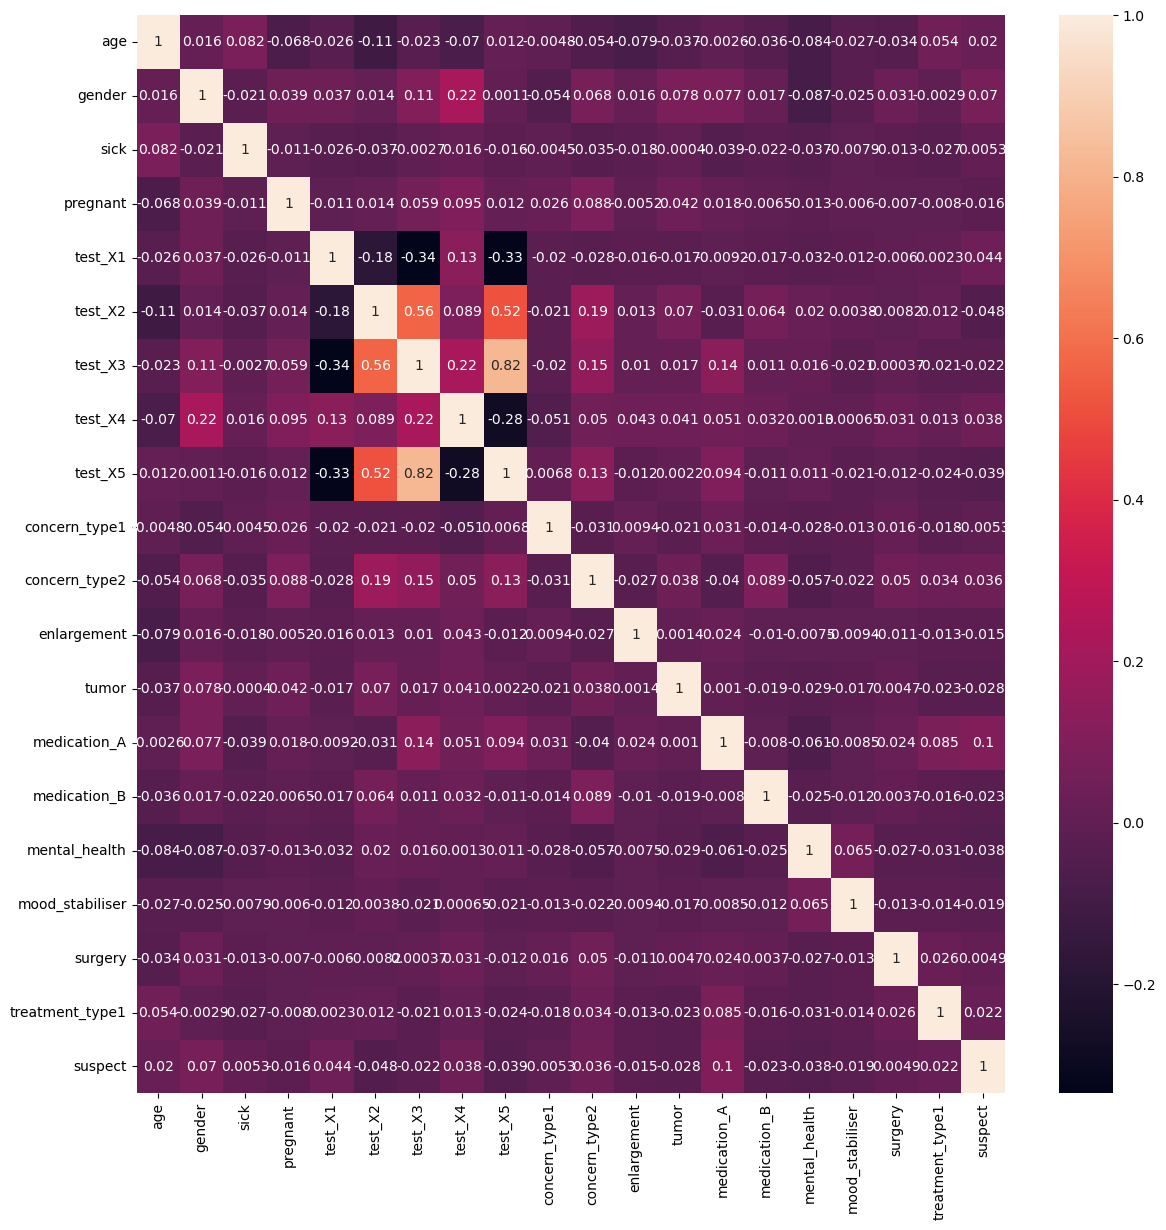

In [157]:
plt.figure(figsize=(14,14))
sns.heatmap(disease_train4.corr(), annot=True)
plt.show()

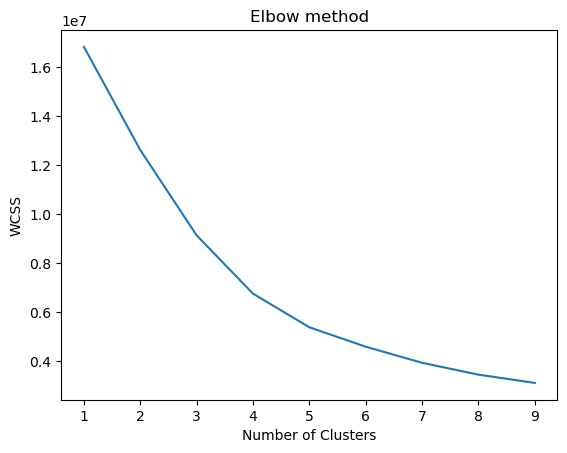

In [158]:
from sklearn.cluster import KMeans

kmeans_models = [KMeans(n_clusters=k).fit(disease_train4) for k in range (1, 10)]
innertia = [model.inertia_ for model in kmeans_models]

plt.plot(range(1, 10), innertia)
plt.title('Elbow method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

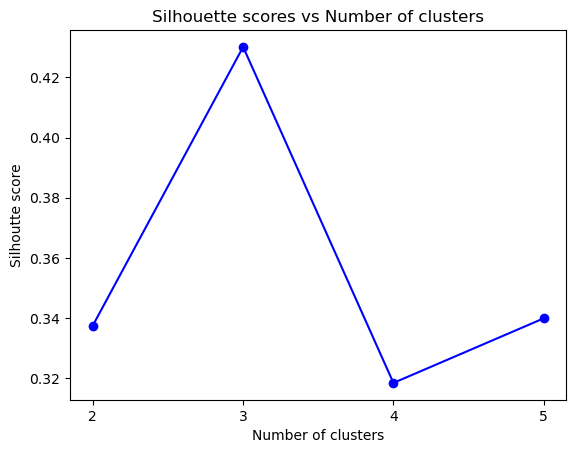

In [159]:
from sklearn.metrics import silhouette_score

silhoutte_scores = [silhouette_score(disease_train4, model.labels_) for model in kmeans_models[1:5]]
plt.plot(range(2,6), silhoutte_scores, "bo-")
plt.xticks([2, 3, 4, 5])
plt.title('Silhouette scores vs Number of clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhoutte score')
plt.show()

In [160]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3,  random_state=23)
kmeans.fit(disease_train4)

print('Silhoutte score of our model is ' + str(silhouette_score(disease_train4, kmeans.labels_)))


Silhoutte score of our model is 0.4338637515235969


In [161]:
#add the cluster ids to the table
disease_train4['id'] = kmeans.labels_

C:\Users\mse98\AppData\Local\Temp\ipykernel_28880\3688292851.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  disease_train4['id'] = kmeans.labels_


In [162]:
for col in cols:
    disease_train4[col] = np.exp(disease_train4[col])


C:\Users\mse98\AppData\Local\Temp\ipykernel_28880\2292713495.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  disease_train4[col] = np.exp(disease_train4[col])


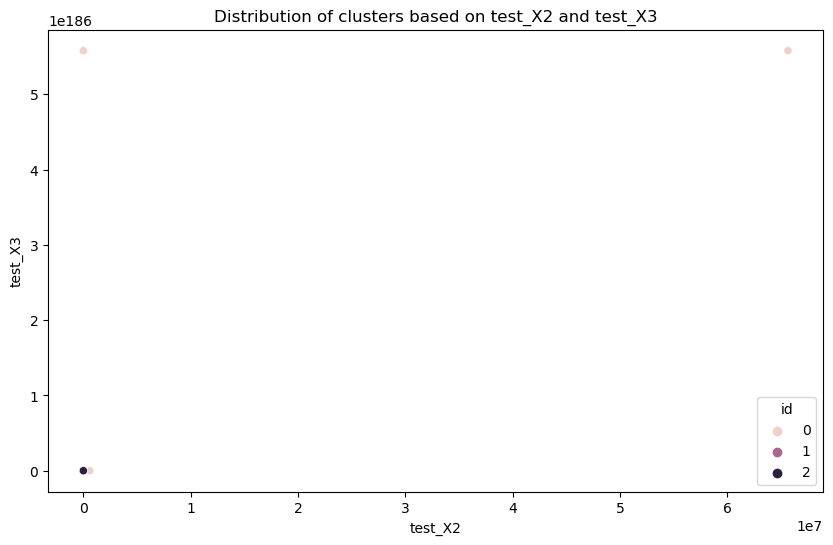

In [163]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=disease_train4, x='test_X2', y='test_X3', hue='id')
plt.title('Distribution of clusters based on test_X2 and test_X3' )
plt.show()

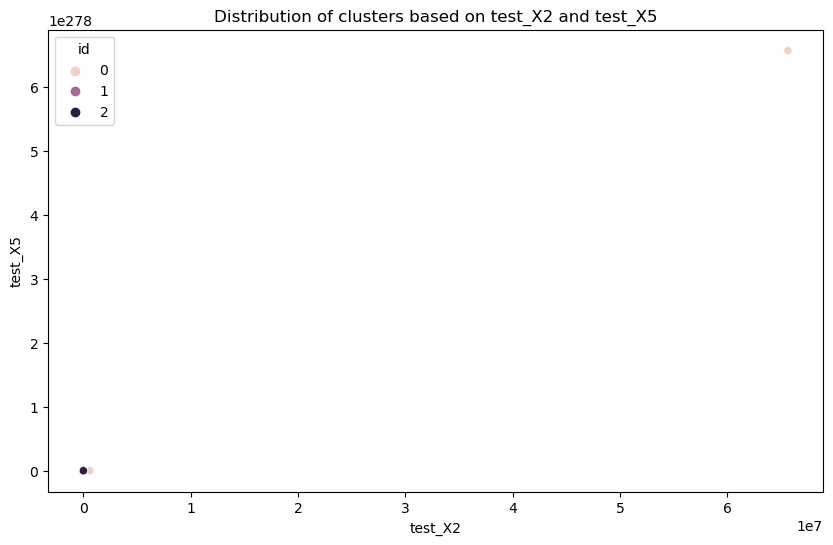

In [164]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=disease_train4, x='test_X2', y='test_X5', hue='id')
plt.title('Distribution of clusters based on test_X2 and test_X5')
plt.show()

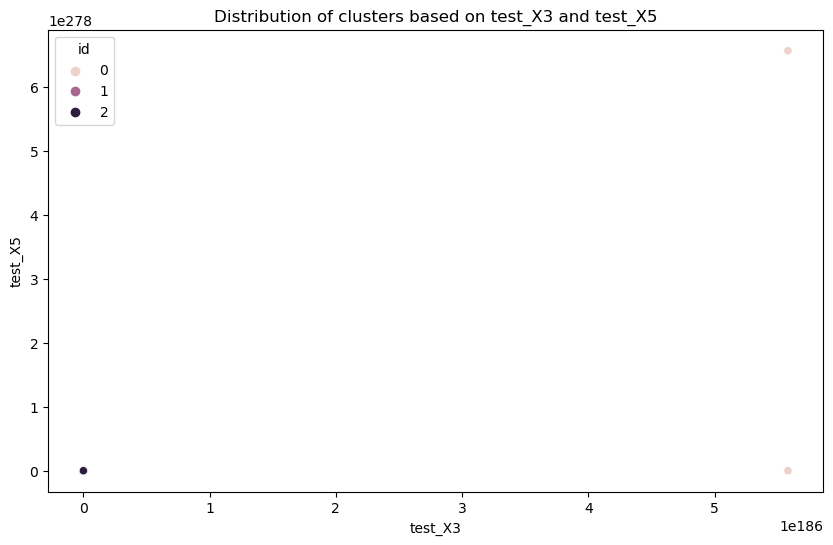

In [165]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=disease_train4, x='test_X3', y='test_X5', hue='id')
plt.title('Distribution of clusters based on test_X3 and test_X5')
plt.show()

## Using just numerical columns

In [166]:
numerical_2 =  ['age', 'test_X1', 'test_X2', 'test_X3',
              'test_X4', 'test_X5']

In [167]:
cols = ['age', 'test_X1', 'test_X2', 'test_X3',
              'test_X4', 'test_X5']

In [168]:
for col in cols:
    disease_train2[col] = np.log1p(disease_train2[col])

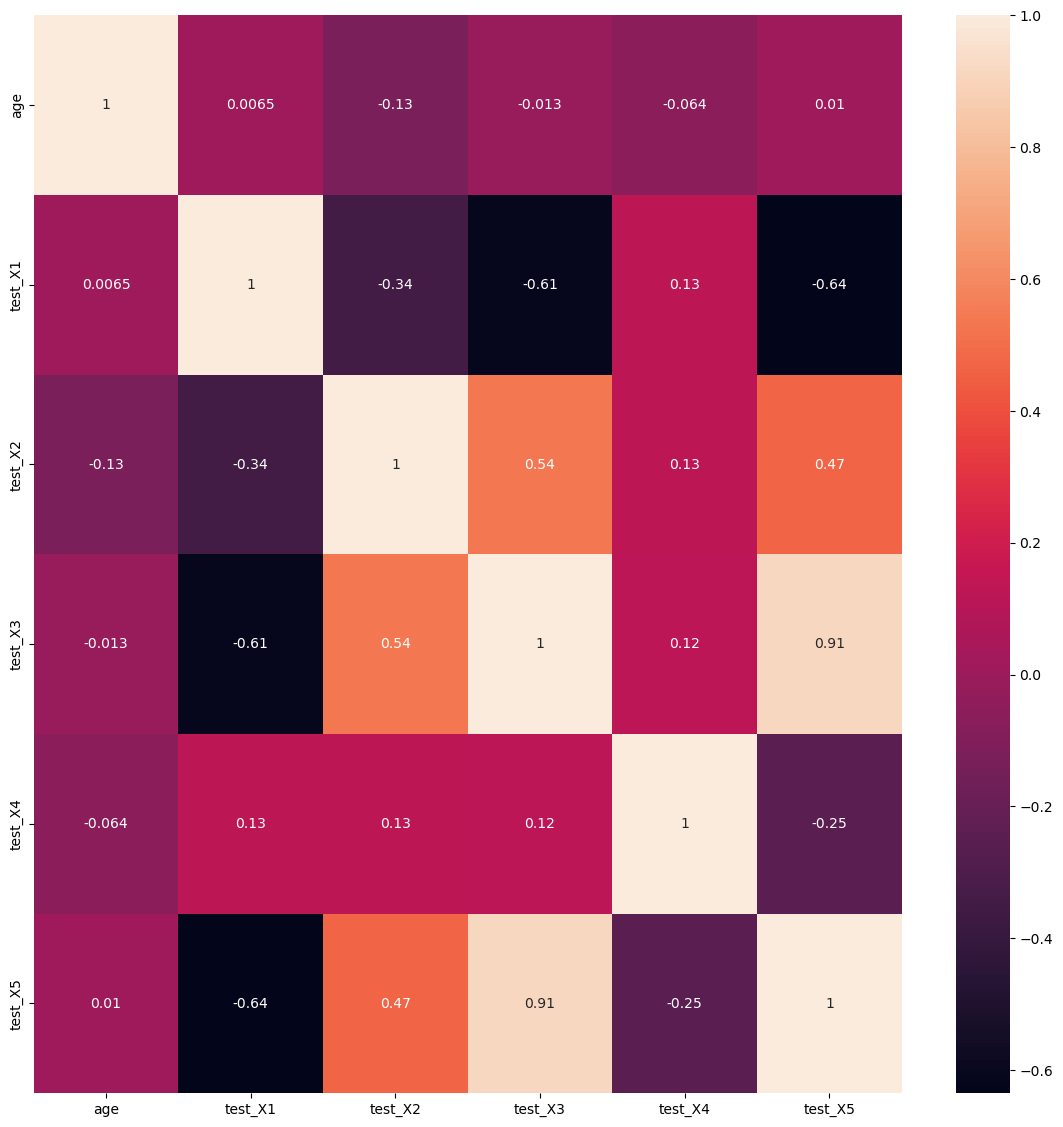

In [169]:
plt.figure(figsize=(14,14))
sns.heatmap(disease_train2[numerical_2].corr(), annot=True)
plt.show()

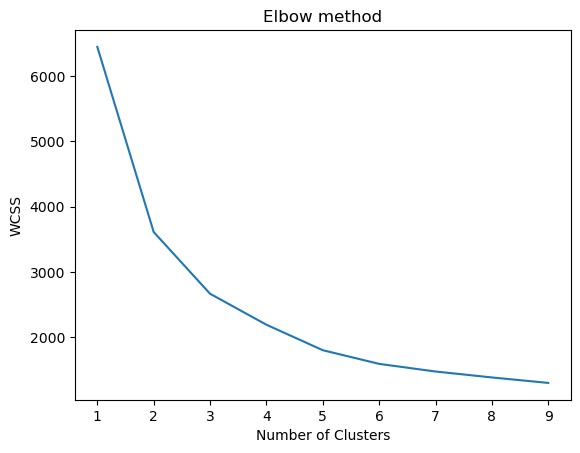

In [170]:
from sklearn.cluster import KMeans

kmeans_models = [KMeans(n_clusters=k).fit(disease_train2[numerical_2]) for k in range (1, 10)]
innertia = [model.inertia_ for model in kmeans_models]

plt.plot(range(1, 10), innertia)
plt.title('Elbow method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

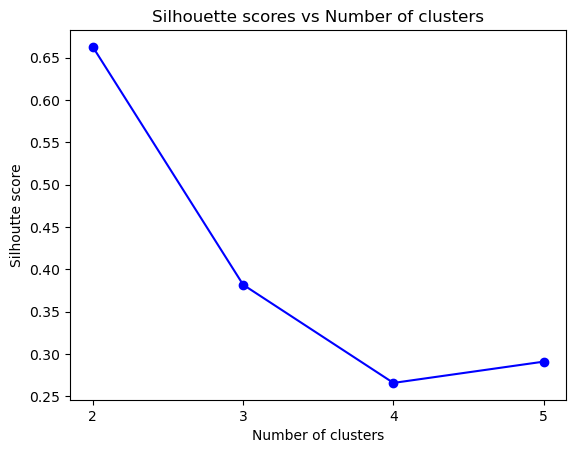

In [171]:
from sklearn.metrics import silhouette_score

silhoutte_scores = [silhouette_score(disease_train2[numerical_2], model.labels_) for model in kmeans_models[1:5]]
plt.plot(range(2,6), silhoutte_scores, "bo-")
plt.xticks([2, 3, 4, 5])
plt.title('Silhouette scores vs Number of clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhoutte score')
plt.show()

In [172]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=2, random_state=23)
kmeans.fit(disease_train2[numerical_2])

print('Silhoutte score of our model is ' + str(silhouette_score(disease_train2[numerical_2], kmeans.labels_)))


Silhoutte score of our model is 0.6625841995317044


In [173]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=23)
kmeans.fit(disease_train2[numerical_2])

print('Silhoutte score of our model is ' + str(silhouette_score(disease_train2[numerical_2], kmeans.labels_)))


Silhoutte score of our model is 0.3788067966383315


In [174]:
#add the cluster ids to the table
disease_train2['cluster_id'] = kmeans.labels_


In [175]:
for col in cols:
    disease_train2[col] = np.exp(disease_train2[col])


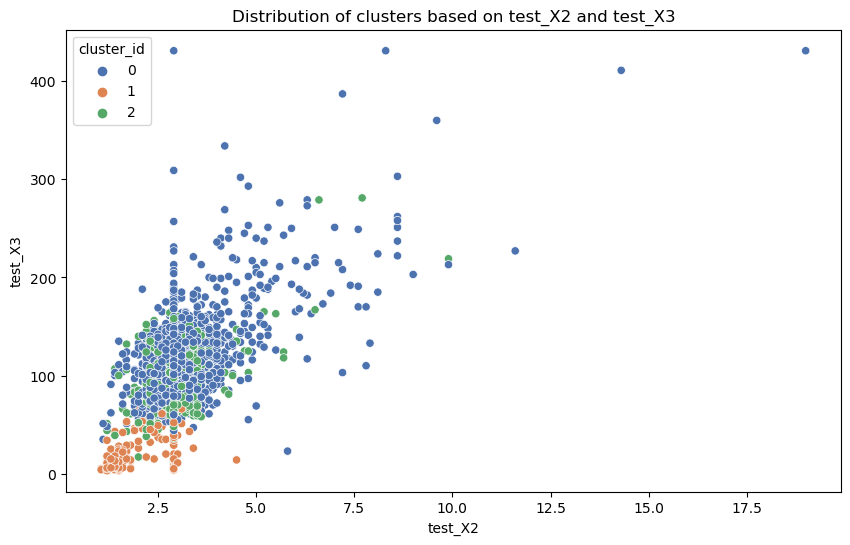

In [176]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=disease_train2, x='test_X2', y='test_X3', hue='cluster_id', palette='deep')
plt.title('Distribution of clusters based on test_X2 and test_X3')
plt.show()

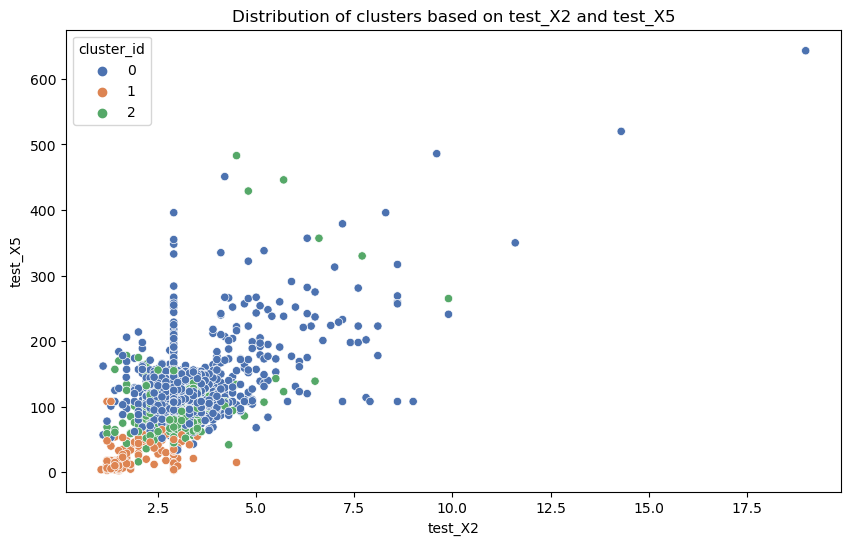

In [177]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=disease_train2, x='test_X2', y='test_X5', hue='cluster_id', palette='deep')
plt.title('Distribution of clusters based on test_X2 and test_X5')
plt.show()

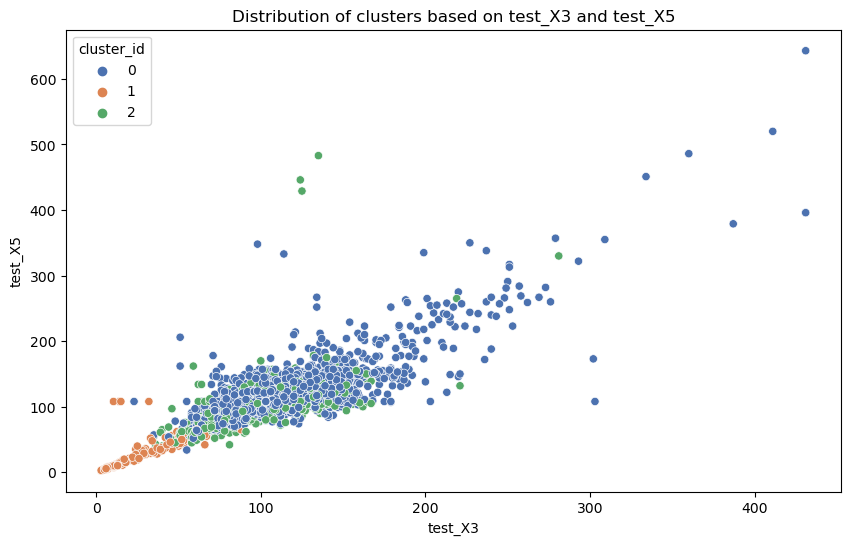

In [178]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=disease_train2, x='test_X3', y='test_X5', hue='cluster_id', palette='deep')
plt.title('Distribution of clusters based on test_X3 and test_X5')
plt.show()

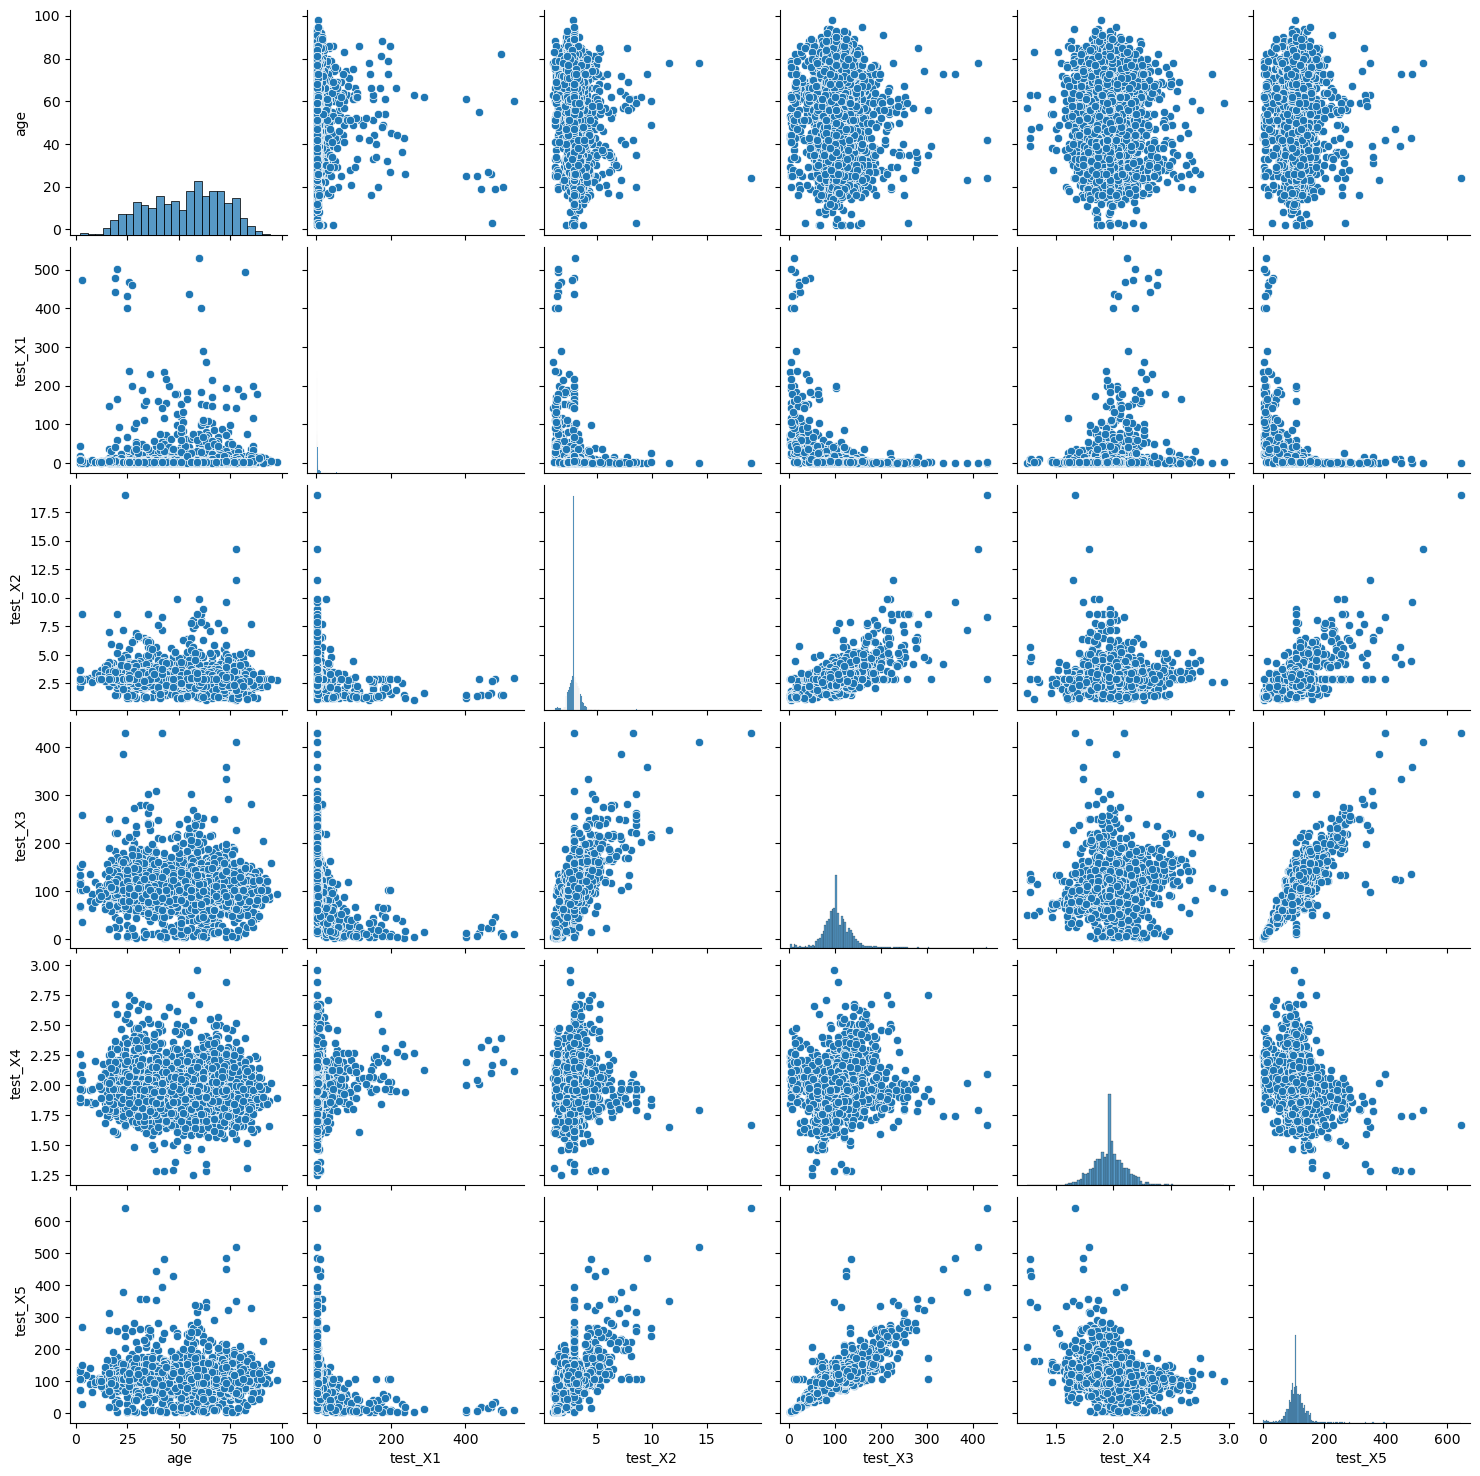

In [179]:
sns.pairplot(disease_train2[numerical_2],kind="scatter")